# HR Attrition Analysis: What Drives Employees to Leave?

## Project Goal

This analysis focuses on a real business problem: employee attrition.

Instead of just measuring how many people leave, the goal is to identify:
- which types of employees are more likely to leave
- what factors are consistently linked with attrition
- which groups the company should focus on first to reduce churn

The output of this analysis is not just charts, but clear risk patterns that can help HR teams take action.

---

## Dataset Overview

This project uses the IBM HR Analytics dataset.

- Total Employees: 1,470
- Features: 30+ (age, salary, job role, satisfaction, overtime, tenure, etc.)
- Data Quality: No missing values, ready for analysis

This dataset represents a structured corporate environment, making it useful for studying real-world attrition patterns.

---

## Tools Used

- SQL (MySQL) → used for core analysis and metric calculations
- Python (Pandas) → used to process and reshape data
- Matplotlib / Seaborn → used to visualize patterns clearly

The focus of this project is not tools, but decision-making using data.

---

## Approach

The analysis follows a structured flow:

1. Data Validation  
   Checked for missing values, duplicates, and consistency to avoid wrong conclusions.

2. SQL-Based Analysis  
   Used SQL to calculate key metrics like:
   - attrition rate by department
   - income vs attrition
   - overtime impact
   - tenure patterns

3. Pattern Exploration  
   Used charts to understand how different factors behave across employees.

4. Risk Identification  
   Combined multiple factors to find high-risk employee groups instead of looking at one variable at a time.

In [1]:
# Suppress warning messages for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Database connection
import mysql.connector
from mysql.connector import Error

# Info 
import logging

#Statistics
from scipy import stats

In [2]:
#The reusable function.

def get_attrition_by(group_col: str) -> pd.DataFrame:
    """
        Calculate attrition summary for a given column.
        Returns total employees, employees who left, and attrition rate.
    """
    query = f"""
    SELECT {group_col}, 
           COUNT(*) as total_employees,                    
           SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) as employees_left,  
           ROUND(SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) as attrition_rate  
    FROM hr_attrition 
    GROUP BY {group_col} 
    ORDER BY attrition_rate DESC                           
    """
    try:
        result = pd.read_sql(query, conn)
        logger.info(f"Attrition Process Completed by '{group_col}': {len(result)} groups loaded")
        return result
    except Exception as e:
        logger.error(f"Failed '{group_col}' query: {e}")
        return pd.DataFrame()  # Safe fallback 

In [3]:
def validate_data(cols: list) -> pd.DataFrame:
    
    # Generate safe SQL with backticks: `MonthlyIncome_nulls`
    null_checks = ', '.join([
        f"SUM(CASE WHEN `{col}` IS NULL THEN 1 ELSE 0 END) AS `{col}_nulls`" 
        for col in cols
    ])
    
    query = f"SELECT {null_checks} FROM `hr_attrition`"
    
    try:
        result = pd.read_sql(query, conn)
        null_total = int(result.iloc[0].sum())
        status = "CLEAN DATA (0 nulls)" if null_total == 0 else f" {null_total} nulls found"
        logger.info(f"Validated {len(cols)} columns: {status}")
        return result
    
    except Exception as e:
        logger.error(f"Validation failed: {e}")
        return pd.DataFrame()

In [4]:
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)

# Initialize
conn = None
df = None

try:
    # Professional connection
    logger.info("Establishing MySQL connection...")
    conn = mysql.connector.connect(
        host="127.0.0.1",
        user="your_username",
        password="your_password",
        database="hr"
    )
    
    if conn.is_connected():
        logger.info("Connection successful")
        
        # Query 1: Full attrition data
        query = "SELECT * FROM hr_attrition"
        df = pd.read_sql(query, conn)
        logger.info(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")
        
    
except Error as e:
    logger.error(f"MySQL Error [{e.errno}]: {e.msg}")
except Exception as e:
    logger.error(f"Unexpected error: {e}")
    
finally:
    # Check connection before close (safe)
    if conn and conn.is_connected():
        logger.info("Connection status check - ready for more queries")

# Always shows DataFrame
df.head()      

2026-04-11 01:41:16,668 - INFO - Establishing MySQL connection...
2026-04-11 01:41:16,695 - INFO - Connection successful
2026-04-11 01:41:16,898 - INFO - Loaded 1470 rows, 32 columns
2026-04-11 01:41:16,898 - INFO - Connection status check - ready for more queries


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,3,4,1,6,3,3,2,2,2,2


## Data Preview

The dataset contains 1,470 employee records with 30+ features covering:
- demographics (age, gender, marital status)
- job-related factors (department, role, income, overtime)
- satisfaction and performance metrics

A quick preview confirms that each row represents a single employee and the `Attrition` column is the target variable (Yes/No).

Before moving to analysis, basic checks were performed to ensure data consistency.

In [5]:
# Log DataFrame structure before display
logger.info("Analyzing DataFrame structure and data types")

# Show column names, non-null counts, and data types
df.info()

2026-04-11 01:41:16,924 - INFO - Analyzing DataFrame structure and data types


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeNumber            1470 non-null   int64 
 9   EnvironmentSatisfaction   1470 non-null   int64 
 10  Gender                    1470 non-null   object
 11  HourlyRate                1470 non-null   int64 
 12  JobInvolvement            1470 non-null   int64 
 13  JobLevel                  1470 non-null   int64 
 14  JobRole                 

## Data Structure Check

The dataset contains 1,470 records and all columns have non-null values.

### Key observations:
- No missing values across any column
- Target variable: `Attrition` (Yes/No)
- Numerical fields: Age, MonthlyIncome, YearsAtCompany, etc.
- Categorical fields: Department, JobRole, OverTime, etc.

### What this means:
The dataset is complete and does not require missing value handling.

In [6]:
# Log before statistical summary
logger.info("Summary statistics displayed - numerical columns analyzed")

# Show summary stats (count, mean, std, min, max, quartiles)
df.describe()

2026-04-11 01:41:16,939 - INFO - Summary statistics displayed - numerical columns analyzed


,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## Summary Statistics (Numerical Features)

This table shows the distribution of key numeric features such as Age, MonthlyIncome, DistanceFromHome, and Satisfaction scores.

### Key observations:

- Age ranges from 18 to 60, with most employees between 30–43 years  
- Monthly income shows a very wide range, indicating large pay differences across roles  
- Distance from home varies significantly, which may influence employee satisfaction or retention  
- Satisfaction-related fields (Environment, Job, Work-Life Balance) are mostly between 2 and 4, suggesting moderate satisfaction levels across employees  

### What this means:

- Income is not evenly distributed, so it should be analyzed carefully against attrition  
- Some features have wide spread, which may indicate strong variation between employee groups  
- These variables are good candidates for deeper analysis (especially income, age, and experience)

In [7]:
null_check = validate_data(['Age', 'MonthlyIncome', 'Attrition', 'JobSatisfaction'])
null_check

2026-04-11 01:41:16,988 - INFO - Validated 4 columns: CLEAN DATA (0 nulls)


,Age_nulls,MonthlyIncome_nulls,Attrition_nulls,JobSatisfaction_nulls
0,0.0,0.0,0.0,0.0


## Missing Value Check

A check across key columns (Age, Income, Attrition, Satisfaction) shows that there are no missing values in the dataset.

### What this means:

- No need for imputation or data cleaning for missing values  
- All records can be used directly for analysis  
- Results will not be affected by data gaps or incomplete entries  

In [8]:
# Log duplicate EmployeeNumber detection
try:
    # SQL: Detect duplicate employee IDs
    query = """
    SELECT 
        EmployeeNumber,
        COUNT(*) AS cnt
    FROM hr_attrition
    GROUP BY EmployeeNumber
    HAVING COUNT(*) > 1
    """
    
    # Find duplicates safely
    duplicates = pd.read_sql(query, conn)
    
    if len(duplicates) == 0:
        logger.info("No duplicate EmployeeNumbers found")
    else:
        logger.warning(f"Found {len(duplicates)} duplicate EmployeeNumbers")
    
except mysql.connector.Error as e:
    logger.error(f"SQL Error [{e.errno}]: {e}")
except Exception as e:
    logger.error(f"Query failed: {e}")

# Display results
duplicates

2026-04-11 01:41:17,000 - INFO - No duplicate EmployeeNumbers found


,EmployeeNumber,cnt


## Duplicate Check

A check on `EmployeeNumber` confirms that each record is unique and there are no duplicate entries.

### What this means:

- Each row represents a distinct employee  
- No risk of double-counting in analysis  

In [9]:
# Log data sanity range checks
logger.info("Running data sanity checks (MIN/MAX ranges)")

try:
    # SQL: Verify data ranges make business sense
    query = """
    SELECT 
        MIN(Age) AS min_age,
        MAX(Age) AS max_age,
        MIN(MonthlyIncome) AS min_income,
        MAX(MonthlyIncome) AS max_income,
        MIN(YearsAtCompany) AS min_years,
        MAX(YearsAtCompany) AS max_years
    FROM hr_attrition
    """
    
    # Check ranges safely
    sanity = pd.read_sql(query, conn)
    
except mysql.connector.Error as e:
    logger.error(f"SQL Error [{e.errno}]: {e}")
except Exception as e:
    logger.error(f"Query failed: {e}")

# Display sanity results
sanity

2026-04-11 01:41:17,005 - INFO - Running data sanity checks (MIN/MAX ranges)


,min_age,max_age,min_income,max_income,min_years,max_years
0,18,60,1009,19999,0,40


Basic range checks show that most values fall within expected limits.

For example:
- Age ranges from 18 to 60
- Years at company ranges from 0 to 40
- Income values are positive

These checks suggest there are no obvious data entry errors, but further analysis (like distributions and outlier detection) is still needed.

In [10]:
# Log key metrics validation
logger.info("Validating total rows vs unique employees")

try:
    # SQL: Check total records vs unique employee count
    query = """
    SELECT COUNT(*) AS total_rows,
           COUNT(DISTINCT EmployeeNumber) AS unique_employees
    FROM hr_attrition
    """
    
    # Validate dataset size
    key_check = pd.read_sql(query, conn)
    
    total = key_check['total_rows'].iloc[0]
    unique = key_check['unique_employees'].iloc[0]
    
 
    if total == unique:
        logger.info("Perfect: 1 row per employee")
    else:
        logger.warning(f"{total - unique} extra rows detected")
    
except mysql.connector.Error as e:
    logger.error(f"SQL Error [{e.errno}]: {e}")
except Exception as e:
    logger.error(f"Query failed: {e}")

# Display key metrics
key_check

2026-04-11 01:41:17,019 - INFO - Validating total rows vs unique employees
2026-04-11 01:41:17,019 - INFO - Perfect: 1 row per employee


,total_rows,unique_employees
0,1470,1470


## Record Consistency Check

The number of rows matches the number of unique employees, confirming that each employee appears only once in the dataset.

In [11]:
# Log overall attrition rate calculation
logger.info("Calculating overall employee attrition rate")

try:
    # SQL: Overall attrition rate (% employees who left)
    query = """
    SELECT
        COUNT(*) AS total_employees,
        SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS employees_left,
        ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS attrition_rate
    FROM hr_attrition
    """
    
    # Calculate key business metric
    overall_attrition = pd.read_sql(query, conn)
    
    left = overall_attrition['employees_left'].iloc[0]
    rate = overall_attrition['attrition_rate'].iloc[0]
    
   
    if rate > 15:
        logger.warning(f"High attrition: {rate}%")
    else:
        logger.info("Healthy attrition rate")
    
except mysql.connector.Error as e:
    logger.error(f"SQL Error [{e.errno}]: {e}")
except Exception as e:
    logger.error(f"Query failed: {e}")

# Display attrition summary
overall_attrition

2026-04-11 01:41:17,032 - INFO - Calculating overall employee attrition rate
2026-04-11 01:41:17,032 - WARNING - High attrition: 16.12%


,total_employees,employees_left,attrition_rate
0,1470,237.0,16.12


## Overall Attrition Rate

Out of 1,470 employees, 237 have left the company, resulting in an attrition rate of 16.12%.

### What this means:

- The majority of employees (around 84%) are staying  
- A smaller but significant portion (16%) has left  

This shows that attrition is not widespread across all employees, but is likely concentrated in specific groups.

### Why this matters:

Instead of treating attrition as a general problem, the next step is to identify which segments (department, role, income, etc.) are driving this 16%.

---

# Phase 1: SQL-Driven Analysis

In this section, I used **SQL queries** to answer key business questions about employee attrition — who is leaving, from which departments, at what income level, and under what conditions and other factors.

---

In [12]:
dept_attrition = get_attrition_by('Department')
dept_attrition

2026-04-11 01:41:17,048 - INFO - Attrition Process Completed by 'Department': 3 groups loaded


,Department,total_employees,employees_left,attrition_rate
0,Sales,446,92.0,20.63
1,Human Resources,63,12.0,19.05
2,Research & Development,961,133.0,13.84


2026-04-11 01:41:17,353 - INFO - Chart created and saved as Department_Attrition_Final.png


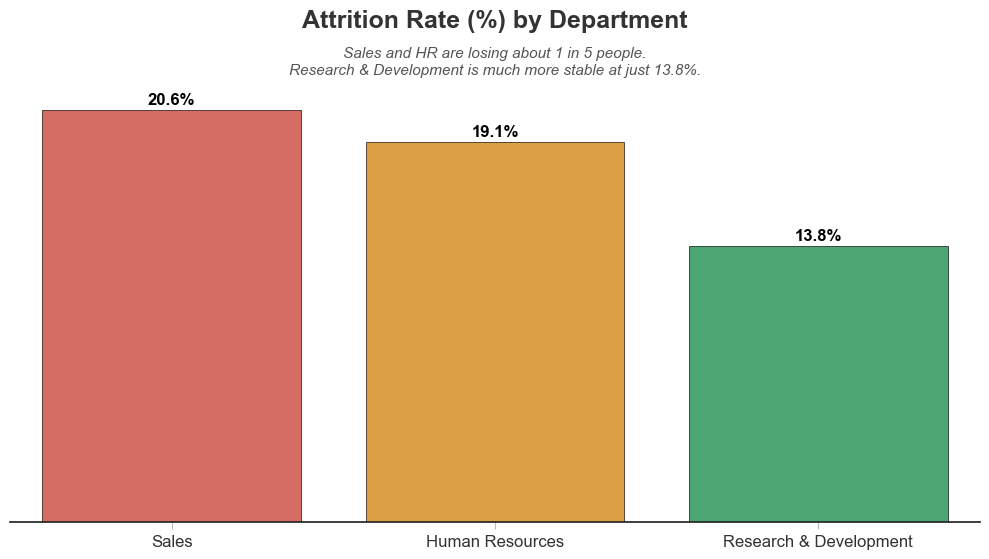

In [13]:
try:
    # Set professional plot style and DPI
    plt.style.use('seaborn-v0_8-white')
    plt.rcParams['figure.dpi'] = 100

    # Create figure with good aspect ratio
    fig, ax = plt.subplots(figsize=(10, 6))

    # HR-themed color palette (Red=High Risk, Green=Stable)
    hr_palette = ["#e74c3c", "#f39c12", "#27ae60"]  # Red, Orange, Green

    # Bar plot: Attrition % by department
    sns.barplot(
        data=dept_attrition,
        x='Department',
        y='attrition_rate',
        ax=ax,
        palette=hr_palette, 
        edgecolor="black", 
        linewidth=0.5,
        alpha=0.9 
    )

    # Add % labels on bars
    for p in ax.patches:
        height = p.get_height()
        label_text = f'{height:.1f}%'
        ax.text(
            p.get_x() + p.get_width() / 2, 
            height + 0.3, 
            label_text,
            ha='center', 
            fontsize=12,
            weight='bold', 
            color='black'
        )

    # Professional title + human subtitle
    ax.set_title("Attrition Rate (%) by Department", fontsize=18, loc='center', pad=45, weight='bold', color="#333333")

    subtitle_text = ("Sales and HR are losing about 1 in 5 people.\n"
                     "Research & Development is much more stable at just 13.8%.")

    ax.text(0.5, 1.03, subtitle_text, transform=ax.transAxes, 
            ha='center', fontsize=11, color="#555555", style='italic', va='bottom')

    # Clean axes (minimalist style)
    ax.tick_params(axis='x', rotation=0, labelsize=12, labelcolor="#333333")
    ax.set_xlabel("") 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False) 
    ax.get_yaxis().set_visible(False) 
    ax.tick_params(axis='y', which='both', length=0)
    ax.tick_params(axis='x', length=5, direction='out', color='#bbbbbb')

    # Layout + high-res export
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig("Department_Attrition_Final.png", dpi=300, bbox_inches='tight', facecolor='white')
    
    logger.info("Chart created and saved as Department_Attrition_Final.png")
    
except Exception as e:
    logger.error(f"Plot failed: {e}")

# Display chart
plt.show()

## Attrition by Department

Sales shows the highest attrition rate at 20.6%, followed by Human Resources at 19.1%.  
Research & Development has a significantly lower attrition rate at 13.8%.

### What this means:

- Employees in Sales are leaving at a much higher rate compared to R&D  
- The gap is not small — attrition in Sales is roughly 50% higher than in R&D  
- This suggests that attrition is not evenly distributed across the company  

### Key insight:

Attrition is concentrated in specific departments, especially Sales and HR.  
This indicates that department-level factors (such as job pressure, targets, or work environment) may be driving employee exits.

In [14]:
jobrole_attrition = get_attrition_by('JobRole')
jobrole_attrition

2026-04-11 01:41:17,431 - INFO - Attrition Process Completed by 'JobRole': 9 groups loaded


,JobRole,total_employees,employees_left,attrition_rate
0,Sales Representative,83,33.0,39.76
1,Laboratory Technician,259,62.0,23.94
2,Human Resources,52,12.0,23.08
3,Sales Executive,326,57.0,17.48
4,Research Scientist,292,47.0,16.10
5,Manufacturing Director,145,10.0,6.90
6,Healthcare Representative,131,9.0,6.87
7,Manager,102,5.0,4.90
8,Research Director,80,2.0,2.50


2026-04-11 01:41:17,448 - INFO - Creating horizontal job role attrition chart


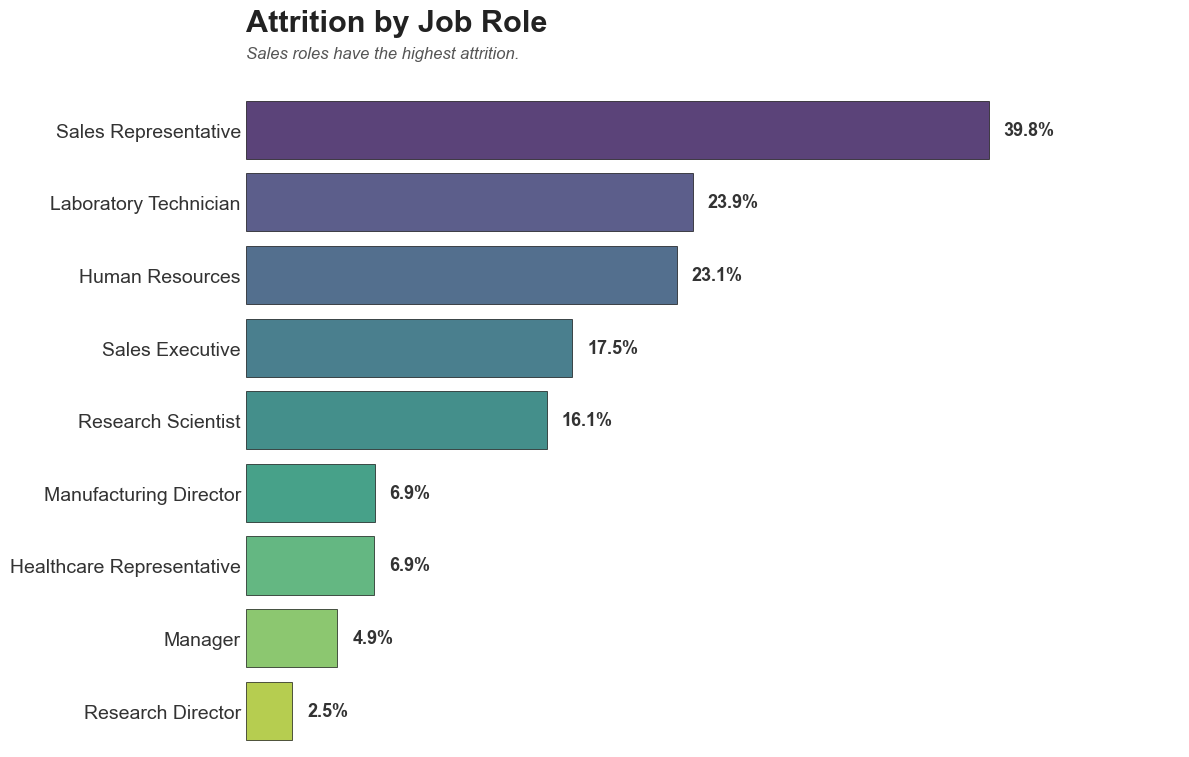

In [15]:
# Log job role attrition visualization
logger.info("Creating horizontal job role attrition chart")

try:
    # Professional plot setup
    plt.style.use('seaborn-v0_8-white')
    plt.rcParams['figure.dpi'] = 100

    # Create larger figure for 9 job roles
    fig, ax = plt.subplots(figsize=(12, 8))

    # Horizontal bar plot (better for long job titles)
    sns.barplot(
        data=jobrole_attrition,
        y='JobRole', 
        x='attrition_rate',
        ax=ax,
        palette="viridis", 
        edgecolor="black", 
        linewidth=0.5,
        alpha=0.9 
    )

    # Add % labels to right of bars (MAGIC STEP)
    for p in ax.patches:
        width = p.get_width()
        label_text = f'{width:.1f}%'
        
        ax.text(
            width + 0.8, 
            p.get_y() + p.get_height() / 2, 
            label_text,
            va='center', 
            fontsize=13,
            weight='bold', 
            color='#333333'
        )

    # Executive title (left-aligned)
    ax.set_title("Attrition by Job Role", 
                 fontsize=22, loc='left', pad=45, weight='bold', color="#222222")

    # Business insight subtitle
    subtitle_text = (
        "Sales roles have the highest attrition."
    )
    ax.text(0, 1.05, subtitle_text, transform=ax.transAxes, 
            fontsize=12, color="#555555", style='italic', va='bottom')

    # Ultra-clean minimalist design
    ax.tick_params(axis='y', labelsize=14, labelcolor="#333333")
    ax.set_ylabel("") 
    ax.set_xlabel("")
    
    # Remove ALL spines and ticks
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.get_xaxis().set_visible(False)
    ax.tick_params(axis='both', which='both', length=0)

    # Prevent label cutoff + set x-limit
    ax.set_xlim(0, 50)

    # Export high-res portfolio image
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig("JobRole_Attrition_Final.png", dpi=300, bbox_inches='tight', facecolor='white')
    
    
except Exception as e:
    logger.error(f"Visualization failed: {e}")

# Display chart
plt.show()

## Attrition by Job Role

Attrition varies significantly across job roles.

- Sales Representatives have the highest attrition at 39.8%  
- Laboratory Technicians and HR roles are also high at around 23%  
- Senior roles like Managers and Research Directors have very low attrition (below 5%)  

### What this means:

- The gap between roles is extremely large — Sales Representatives are leaving at a rate nearly 15–16 times higher than Research Directors  
- Attrition is heavily concentrated in specific operational roles, especially in Sales  
- Senior and specialized roles show strong retention, suggesting stability at higher levels  

### Key insight:

This is not a company-wide problem — it is role-specific.

High attrition in Sales roles may be driven by factors like:
- high pressure targets  
- variable compensation  
- job dissatisfaction or burnout  

This makes Sales Representative the highest priority role for retention efforts.

In [16]:
# Log income vs attrition analysis
logger.info("Analyzing income patterns by attrition status")

try:
    # SQL: Compare salaries between employees who stayed vs left
    query = """
    SELECT 
        Attrition,
        ROUND(AVG(MonthlyIncome), 2) AS avg_monthly_income,
        ROUND(MIN(MonthlyIncome), 2) AS min_income,
        ROUND(MAX(MonthlyIncome), 2) AS max_income
    FROM hr_attrition
    GROUP BY Attrition
    """
    
    # Load income comparison
    income_attrition = pd.read_sql(query, conn)
    
    # Log key insight
    stayed_avg = income_attrition[income_attrition['Attrition']=='No']['avg_monthly_income'].iloc[0]
    left_avg = income_attrition[income_attrition['Attrition']=='Yes']['avg_monthly_income'].iloc[0]
    
    
except mysql.connector.Error as e:
    logger.error(f"SQL Error [{e.errno}]: {e}")
except Exception as e:
    logger.error(f"Query failed: {e}")

# Display income vs attrition table
income_attrition

2026-04-11 01:41:18,023 - INFO - Analyzing income patterns by attrition status


,Attrition,avg_monthly_income,min_income,max_income
0,Yes,4787.09,1009,19859
1,No,6832.74,1051,19999


2026-04-11 01:41:18,346 - INFO - Income boxplot created successfully: Leavers vs Stayers


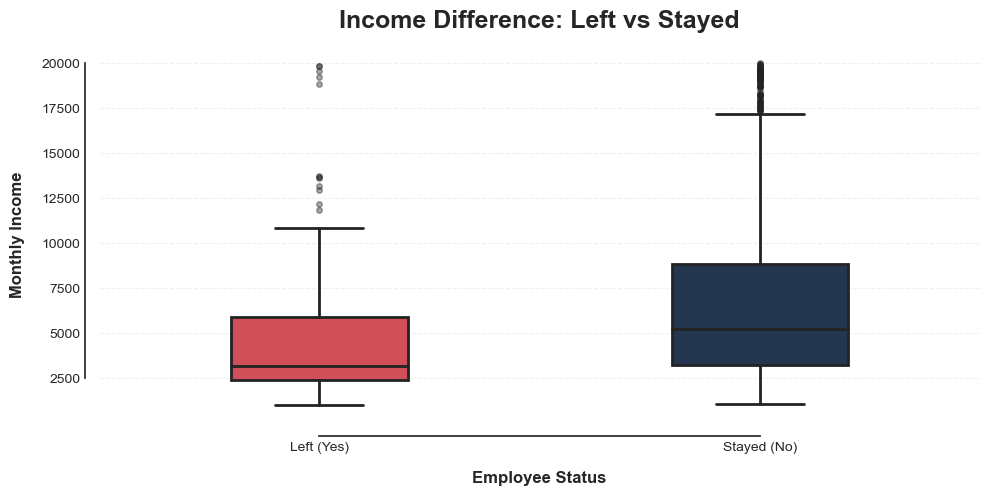

In [17]:
try:
    # Load raw income data for visualization
    query = """
    SELECT Attrition, MonthlyIncome
    FROM hr_attrition
    """
    income_data = pd.read_sql(query, conn)
    

    # Initialize professional figure
    fig, ax = plt.subplots(figsize=(10, 6))

    # Boxplot: Income distribution by attrition status
    sns.boxplot(
        data=income_data, 
        x='Attrition', 
        y='MonthlyIncome', 
        ax=ax,
        palette=['#E63946', '#1D3557'],  # Red=Left, DarkBlue=Stayed
        width=0.4,
        linewidth=2,
        showfliers=True,
        flierprops={"marker": "o", "markersize": 4, "alpha": 0.4}
    )

    # Executive title + insight subtitle
    ax.text(x=0.5, y=1.05, s='Income Difference: Left vs Stayed', 
            fontsize=18, fontweight='bold', ha='center', transform=ax.transAxes)

    ax.text(x=0.5, y=1.02, 
            s=(""), 
            fontsize=11, color='#444444', ha='center', transform=ax.transAxes)

    # Professional axis labels
    ax.set_xlabel('Employee Status', fontsize=12, fontweight='bold', labelpad=12)
    ax.set_ylabel('Monthly Income', fontsize=12, fontweight='bold', labelpad=12)
    ax.set_xticklabels(['Left (Yes)', 'Stayed (No)'], fontsize=11)

    # Clean styling with subtle grid
    ax.yaxis.grid(True, linestyle='--', alpha=0.3) 
    sns.despine(ax=ax, offset=10, trim=True)        

    # Layout adjustment for titles
    fig.tight_layout(rect=[0, 0, 1, 0.85])
    plt.savefig("Monthly_Income_Attrition.png", dpi=300, bbox_inches='tight', facecolor='white')
    logger.info("Income boxplot created successfully: Leavers vs Stayers")
    
except mysql.connector.Error as e:
    logger.error(f"SQL Error [{e.errno}]: {e}")
except Exception as e:
    logger.error(f"Visualization failed: {e}")

# Display the boxplot
plt.show()

## Income vs Attrition

Employees who left the company generally have lower income compared to those who stayed.

- Average income (Left): ~4787  
- Average income (Stayed): ~6833  

### What the distribution shows:

- The median income of employees who left is clearly lower  
- Employees who stayed show a wider income range, including many high earners  
- There is still overlap — some low-income employees stayed, and some high-income employees left  

### What this means:

- Income appears to be an important factor, but not the only driver of attrition  
- Lower salary may increase the likelihood of leaving, but it does not fully explain employee behavior  

### Key insight:

Attrition is more common among lower-income employees, but salary alone cannot explain it. Other factors (like job role, overtime, or satisfaction) must also be influencing employee decisions.

In [18]:
overtime_attrition = get_attrition_by('OverTime')
overtime_attrition

2026-04-11 01:41:18,424 - INFO - Attrition Process Completed by 'OverTime': 2 groups loaded


,OverTime,total_employees,employees_left,attrition_rate
0,Yes,416,127.0,30.53
1,No,1054,110.0,10.44


2026-04-11 01:41:18,435 - INFO - Creating overtime vs attrition bar chart
2026-04-11 01:41:18,703 - INFO - Overtime chart created - 3x attrition risk visualized


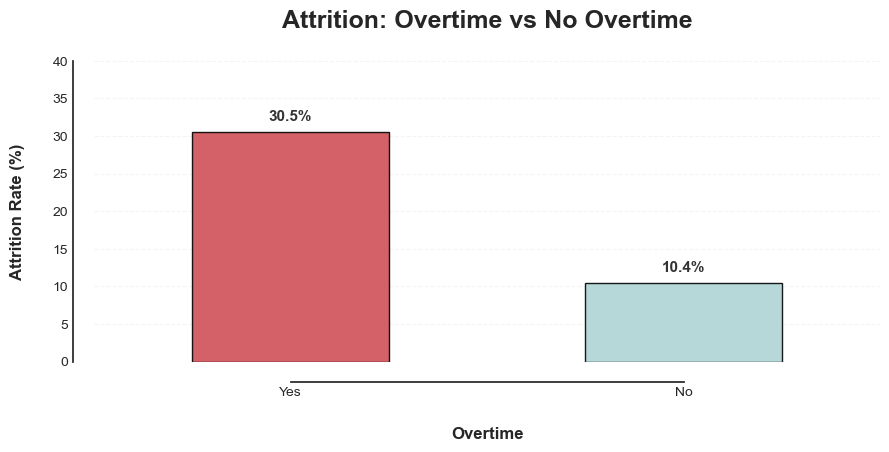

In [19]:
# Log overtime attrition visualization (3x risk confirmed)
logger.info("Creating overtime vs attrition bar chart")

try:
    # Optimized figure size for 2 bars
    fig, ax = plt.subplots(figsize=(9, 6))

    # Narrow bars with breathing room
    sns.barplot(
        data=overtime_attrition, 
        x='OverTime', 
        y='attrition_rate', 
        ax=ax,
        palette=['#E63946', '#A8DADC'],  # Red=Danger, LightBlue=Safe
        edgecolor='black',
        linewidth=1,
        width=0.5,  # Narrower = more whitespace
        alpha=0.9
    )

    # Precise data labels with padding
    for i, v in enumerate(overtime_attrition['attrition_rate']):
        ax.text(i, v + 1.5, f"{v:.1f}%", ha='center', fontsize=11, fontweight='bold', color='#333333')

    # Executive title (higher position)
    ax.text(x=0.5, y=1.11, s='Attrition: Overtime vs No Overtime', 
            fontsize=18, fontweight='bold', ha='center', transform=ax.transAxes)

    # Business-critical subtitle
    ax.text(x=0.5, y=1.03, 
            s=(''), 
            fontsize=11, color='#555555', ha='center', transform=ax.transAxes, linespacing=1.6)

    # Professional axes
    ax.set_xlabel('Overtime', fontsize=12, fontweight='bold', labelpad=20)
    ax.set_ylabel('Attrition Rate (%)', fontsize=12, fontweight='bold', labelpad=20)
    ax.set_ylim(0, 40)  # Room for labels

    # Clean design with subtle grid
    sns.despine(ax=ax, offset=15, trim=True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.2)

    # Perfect layout spacing
    fig.tight_layout(rect=[0, 0, 1, 0.80])
    plt.savefig("Overtime_Attrition.png", dpi=300, bbox_inches='tight', facecolor='white')
    logger.info("Overtime chart created - 3x attrition risk visualized")
    
except Exception as e:
    logger.error(f"Chart failed: {e}")

# Display the visualization
plt.show()

## Overtime vs Attrition

Employees who work overtime have a much higher attrition rate compared to those who do not.

- Overtime (Yes): 30.5%  
- Overtime (No): 10.4%  

### What this means:

- Employees working overtime are leaving at nearly 3 times the rate of those who are not  
- This is one of the largest gaps observed so far in the analysis  

### Important note:

This does not prove that overtime causes attrition, but it shows a strong relationship between the two.

### Key insight:

Overtime is a major risk indicator for attrition. Employees working overtime form a high-risk group and should be a priority for deeper investigation and retention strategies.

In [20]:
# Log tenure vs attrition analysis
logger.info("Analyzing employee tenure by attrition status")

try:
    # SQL: Years at company comparison (stayers vs leavers)
    query = """
    SELECT
        Attrition,
        ROUND(AVG(YearsAtCompany), 2) AS avg_years,
        MIN(YearsAtCompany) AS min_years,
        MAX(YearsAtCompany) AS max_years
    FROM hr_attrition
    GROUP BY Attrition
    """
    
    # Load tenure comparison
    years_summary = pd.read_sql(query, conn)
    
    # Key insight logging
    stayed_avg = years_summary[years_summary['Attrition']=='No']['avg_years'].iloc[0]
    left_avg = years_summary[years_summary['Attrition']=='Yes']['avg_years'].iloc[0]
    
    
except mysql.connector.Error as e:
    logger.error(f"SQL Error [{e.errno}]: {e}")
except Exception as e:
    logger.error(f"Query failed: {e}")

# Display tenure summary table
years_summary

2026-04-11 01:41:18,775 - INFO - Analyzing employee tenure by attrition status


,Attrition,avg_years,min_years,max_years
0,Yes,5.13,0,40
1,No,7.37,0,37


2026-04-11 01:41:19,072 - INFO - Tenure boxplot created - new hires leave fastest


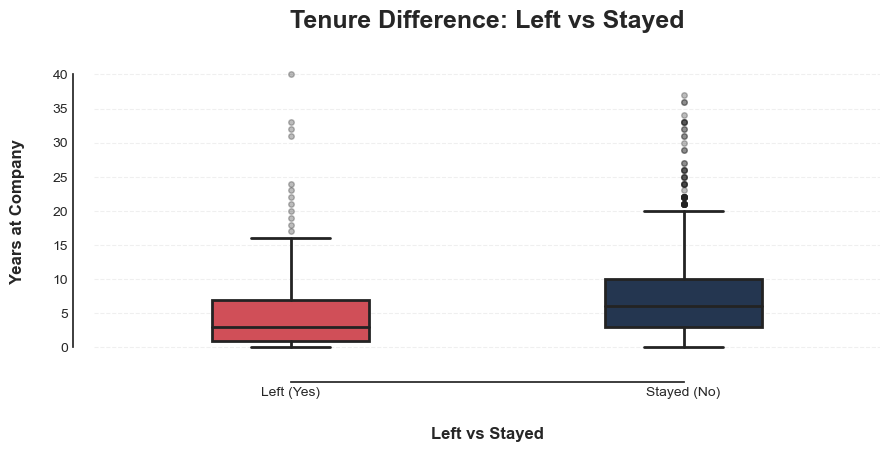

In [21]:
try:
    # Load raw tenure data
    query = """
    SELECT Attrition, YearsAtCompany
    FROM hr_attrition
    """
    years_data = pd.read_sql(query, conn)

    # Figure with extra height for header
    fig, ax = plt.subplots(figsize=(9, 6))

    # Boxplot: Tenure distribution by attrition
    sns.boxplot(
        data=years_data, 
        x='Attrition', 
        y='YearsAtCompany', 
        ax=ax,
        palette=['#E63946', '#1D3557'],  # Red=Left, Navy=Stayed (consistent)
        width=0.4,                      # Narrow boxes = more whitespace
        linewidth=2,
        showfliers=True,
        flierprops={"marker": "o", "markersize": 4, "alpha": 0.3}
    )

    # Executive title (higher y-position)
    ax.text(x=0.5, y=1.11, s='Tenure Difference: Left vs Stayed', 
            fontsize=18, fontweight='bold', ha='center', transform=ax.transAxes)

    # Insight-driven subtitle
    ax.text(x=0.5, y=1.12, 
            s=(''), 
            fontsize=11, color='#444444', ha='center', transform=ax.transAxes, linespacing=1.6)

    # Professional axis labels
    ax.set_xlabel('Left vs Stayed', fontsize=12, fontweight='bold', labelpad=20)
    ax.set_ylabel('Years at Company', fontsize=12, fontweight='bold', labelpad=20)
    ax.set_xticklabels(['Left (Yes)', 'Stayed (No)'], fontsize=11)

    # Elegant styling
    ax.yaxis.grid(True, linestyle='--', alpha=0.3) 
    sns.despine(ax=ax, offset=15, trim=True)

    # Perfect spacing for titles
    fig.tight_layout(rect=[0, 0, 1, 0.80])
    plt.savefig("Tenure_Attrition.png", dpi=300, bbox_inches='tight', facecolor='white')
    logger.info("Tenure boxplot created - new hires leave fastest")
    
except mysql.connector.Error as e:
    logger.error(f"SQL Error [{e.errno}]: {e}")
except Exception as e:
    logger.error(f"Visualization failed: {e}")

# Display boxplot
plt.show()

## Tenure vs Attrition

Employees who leave the company tend to have shorter tenure compared to those who stay.

- Average tenure (Left): ~5.1 years  
- Average tenure (Stayed): ~7.4 years  

### What the distribution shows:

- A large number of employees leave within the first few years  
- Employees who stay tend to move beyond this early period and remain longer  
- The risk of attrition appears highest in the early stage of employment  

### Key insight:

- Attrition is concentrated in the first 3–5 years of employment.
- This suggests that early employee experience (onboarding, role clarity, job satisfaction) is critical.
- Improving retention efforts during this period could significantly reduce overall attrition.

In [22]:
# Log age group attrition analysis (5 cohorts)
logger.info("Analyzing attrition by age cohort (18-25 through 55+)")

try:
    # SQL: Create age bands + attrition rates (chronological order)
    query = """
    SELECT 
        CASE 
            WHEN Age BETWEEN 18 AND 25 THEN '18-25'
            WHEN Age BETWEEN 26 AND 35 THEN '26-35'
            WHEN Age BETWEEN 36 AND 45 THEN '36-45'
            WHEN Age BETWEEN 46 AND 55 THEN '46-55'
            ELSE '55+'
        END AS age_group,
        COUNT(*) AS total_employees,
        SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS employees_left,
        ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS attrition_rate
    FROM hr_attrition
    GROUP BY age_group
    ORDER BY 
        CASE 
            WHEN age_group = '18-25' THEN 1
            WHEN age_group = '26-35' THEN 2
            WHEN age_group = '36-45' THEN 3
            WHEN age_group = '46-55' THEN 4
            ELSE 5
        END
    """
    
    # Load age cohort analysis
    age_attrition = pd.read_sql(query, conn)
    
    
except mysql.connector.Error as e:
    logger.error(f"SQL Error [{e.errno}]: {e}")
except Exception as e:
    logger.error(f"Query failed: {e}")

# Display age group attrition table
age_attrition

2026-04-11 01:41:19,138 - INFO - Analyzing attrition by age cohort (18-25 through 55+)


,age_group,total_employees,employees_left,attrition_rate
0,18-25,123,44.0,35.77
1,26-35,606,116.0,19.14
2,36-45,468,43.0,9.19
3,46-55,226,26.0,11.50
4,55+,47,8.0,17.02


2026-04-11 01:41:19,158 - INFO - Creating age group attrition bar chart (5 cohorts)


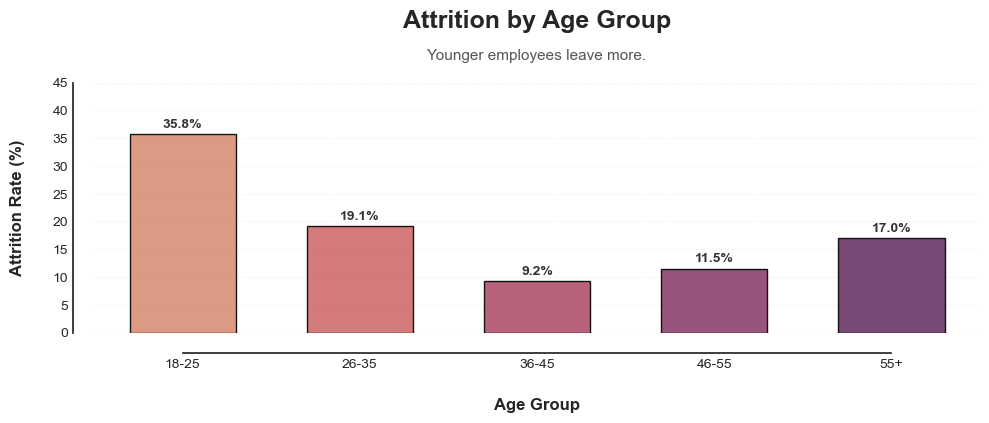

In [23]:
# Log age cohort attrition visualization
logger.info("Creating age group attrition bar chart (5 cohorts)")

try:
    # Professional figure setup
    fig, ax = plt.subplots(figsize=(10, 6))

    # Gradient barplot (flare = professional sequential)
    sns.barplot(
        data=age_attrition, 
        x='age_group', 
        y='attrition_rate', 
        ax=ax,
        palette='flare', 
        edgecolor='black',
        linewidth=1,
        width=0.6,
        alpha=0.9
    )

    # Precise % labels above bars
    for i, v in enumerate(age_attrition['attrition_rate']):
        ax.text(i, v + 1.2, f"{v:.1f}%", ha='center', fontsize=10, fontweight='bold', color='#333333')

    # Executive title (top center)
    ax.text(x=0.5, y=1.22, s='Attrition by Age Group', 
            fontsize=18, fontweight='bold', ha='center', transform=ax.transAxes)

    # Actionable business subtitle
    ax.text(x=0.5, y=1.09, 
            s='Younger employees leave more.', 
            fontsize=11, color='#555555', ha='center', transform=ax.transAxes, linespacing=1.6)

    # Clean professional axes
    ax.set_xlabel('Age Group', fontsize=12, fontweight='bold', labelpad=20)
    ax.set_ylabel('Attrition Rate (%)', fontsize=12, fontweight='bold', labelpad=20)
    ax.set_ylim(0, 45)  # Space for labels

    # Elegant minimalist styling
    sns.despine(ax=ax, offset=15, trim=True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.2)

    # Perfect layout for titles
    fig.tight_layout(rect=[0, 0, 1, 0.80])
    plt.savefig("Age_Group_Attrition.png", dpi=300, bbox_inches='tight', facecolor='white')
    
except Exception as e:
    logger.error(f"Visualization failed: {e}")

# Display the age attrition chart
plt.show()

## Age Groups vs Attrition

Attrition varies significantly across age groups.

- 18–25: Highest attrition (~35.8%)  
- 26–35: Still elevated (~19.1%)  
- 36–45: Lowest attrition (~9.2%)  
- 46–55: Slight increase (~11.5%)  
- 55+: Further increase (~17%)  

### What this means:

- Attrition is highest in early career stages  
- It decreases as employees move into mid-career (36–45), where stability is highest  
- A slight increase in later years may reflect retirement planning or role transitions  

### Key insight:

The highest risk period is early career (18–35).

This suggests that younger employees are more likely to leave, possibly due to:
- career exploration  
- better opportunities  
- dissatisfaction with early roles  

### Business implication:

Retention strategies should focus heavily on early-career employees, especially in their first few years, where attrition risk is highest.

In [24]:
# Log top 5 roles losing most employees (absolute numbers)
logger.info("Finding top 5 job roles by raw attrition count")

try:
    # SQL: Raw headcount loss by job role (top 5 worst)
    query = """
    SELECT 
        JobRole,
        SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS employees_left
    FROM hr_attrition
    GROUP BY JobRole
    ORDER BY employees_left DESC
    LIMIT 5
    """
    
    # Load top 5 attrition roles
    top5_attrition = pd.read_sql(query, conn)
    
    
except mysql.connector.Error as e:
    logger.error(f"SQL Error [{e.errno}]: {e}")
except Exception as e:
    logger.error(f"Query failed: {e}")

# Display top 5 attrition roles
top5_attrition

2026-04-11 01:41:19,573 - INFO - Finding top 5 job roles by raw attrition count


,JobRole,employees_left
0,Laboratory Technician,62.0
1,Sales Executive,57.0
2,Research Scientist,47.0
3,Sales Representative,33.0
4,Human Resources,12.0


2026-04-11 01:41:19,590 - INFO - Creating top 5 attrition roles bar chart


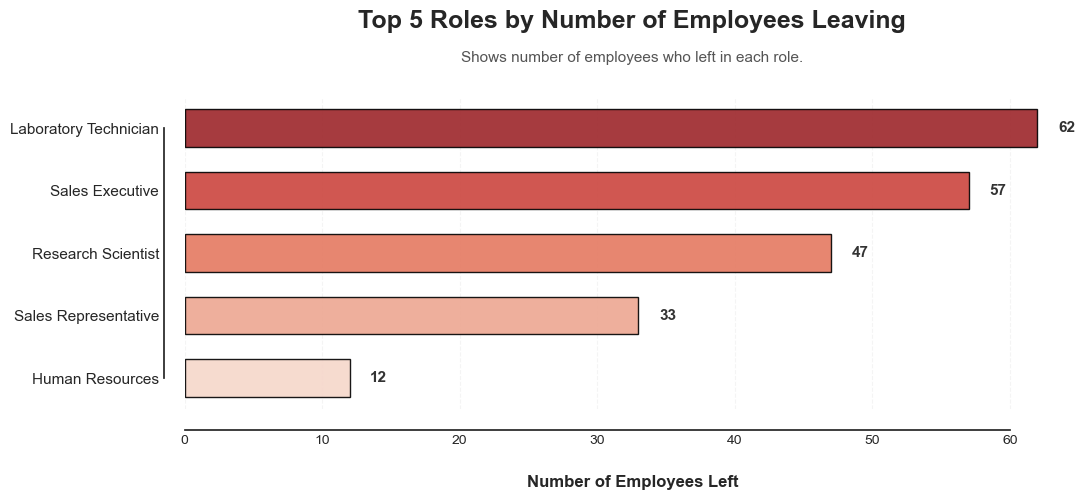

In [25]:
# Log top 5 attrition roles by absolute employee loss
logger.info("Creating top 5 attrition roles bar chart")

try:
    # Wider figure for long job titles
    fig, ax = plt.subplots(figsize=(11, 7))

    # Horizontal bars make role names easier to read
    sns.barplot(
        data=top5_attrition, 
        x='employees_left', 
        y='JobRole', 
        ax=ax,
        palette='Reds_r',   # Darker red = higher loss
        edgecolor='black',
        linewidth=1,
        width=0.6,
        alpha=0.9
    )

    # Add employee count labels at bar ends
    for i, v in enumerate(top5_attrition['employees_left']):
        ax.text(v + 1.5, i, f"{int(v)}", va='center', fontsize=11, fontweight='bold', color='#333333')

    # Clean centered title
    ax.text(x=0.5, y=1.22, s='Top 5 Roles by Number of Employees Leaving', 
            fontsize=18, fontweight='bold', ha='center', transform=ax.transAxes)

    # Simple business-focused subtitle
    ax.text(x=0.5, y=1.11, 
            s='Shows number of employees who left in each role.', 
            fontsize=11, color='#555555', ha='center', transform=ax.transAxes, linespacing=1.6)

    # Axis labels and clean ticks
    ax.set_xlabel('Number of Employees Left', fontsize=12, fontweight='bold', labelpad=20)
    ax.set_ylabel('', fontsize=12)
    ax.tick_params(axis='y', labelsize=11)

    # Minimal styling
    sns.despine(ax=ax, offset=15, trim=True)
    ax.xaxis.grid(True, linestyle='--', alpha=0.2)

    # Space for header
    fig.tight_layout(rect=[0, 0, 1, 0.80])
    plt.savefig("Top_5_Attrition.png", dpi=300, bbox_inches='tight', facecolor='white')
    
except Exception as e:
    logger.error(f"Visualization failed: {e}")

# Show the plot
plt.show()

## Attrition Volume by Job Role

This chart shows the number of employees who left in each role (not the attrition rate).

- Laboratory Technicians (62) and Sales Executives (57) have the highest number of exits  
- Research Scientists and Sales Representatives also show notable attrition volume  

### Important distinction:

This reflects total exits, not risk.

Larger teams will naturally have higher counts, so this should not be confused with attrition rate.

### Key insight:

There is a clear difference between volume and risk:

- Sales Representatives have the highest attrition rate (~40%)  
- But they are not the highest in total exits  

This means:
- Some roles have fewer people but very high risk  
- Others have large teams and therefore higher total exits  

### Business implication:

Both perspectives matter:

- High-risk roles → need targeted retention strategies  
- High-volume roles → need operational focus due to impact on workforce size  

Combining both will give a more complete picture of attrition.

In [26]:
# Log job satisfaction vs attrition analysis (1-4 scale)
logger.info("Analyzing job satisfaction correlation with attrition")

try:
    # SQL: Attrition rate by satisfaction level (Low=1 to High=4)
    query = """
    SELECT 
        JobSatisfaction,
        COUNT(*) AS total_employees,
        SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS employees_left,
        ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS attrition_rate
    FROM hr_attrition
    GROUP BY JobSatisfaction
    ORDER BY JobSatisfaction
    """
    
    # Load satisfaction breakdown
    satisfaction_attrition = pd.read_sql(query, conn)
    
    
except mysql.connector.Error as e:
    logger.error(f"SQL Error [{e.errno}]: {e}")
except Exception as e:
    logger.error(f"Query failed: {e}")

# Display satisfaction attrition table
satisfaction_attrition

2026-04-11 01:41:20,030 - INFO - Analyzing job satisfaction correlation with attrition


,JobSatisfaction,total_employees,employees_left,attrition_rate
0,1,289,66.0,22.84
1,2,280,46.0,16.43
2,3,442,73.0,16.52
3,4,459,52.0,11.33


2026-04-11 01:41:20,052 - INFO - Creating job satisfaction vs attrition bar chart


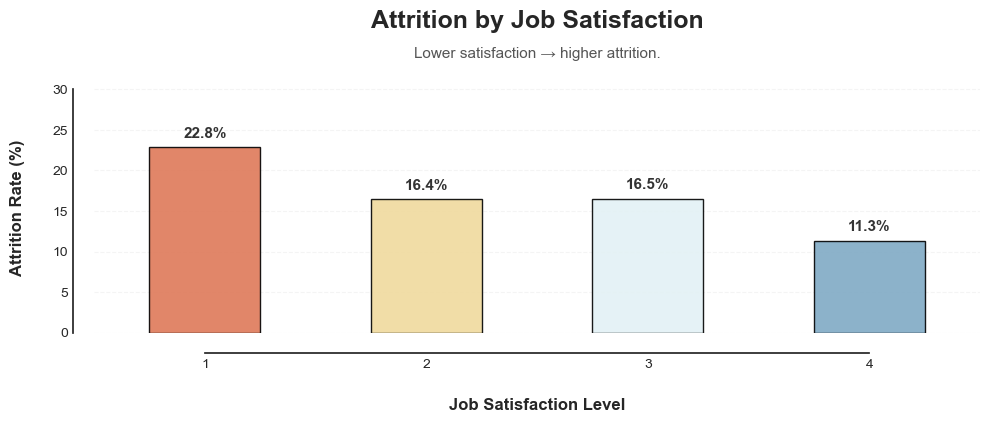

In [27]:
# Log job satisfaction attrition visualization
logger.info("Creating job satisfaction vs attrition bar chart")

try:
    # Professional figure setup
    fig, ax = plt.subplots(figsize=(10, 6))

    # Sequential palette shows satisfaction → retention trend
    sns.barplot(
        data=satisfaction_attrition, 
        x='JobSatisfaction', 
        y='attrition_rate', 
        ax=ax,
        palette='RdYlBu',  # Red=Low Sat → High Attrition, Blue=High Sat → Low Attrition
        edgecolor='black',
        linewidth=1,
        width=0.5,
        alpha=0.9
    )

    # % labels above each bar
    for i, v in enumerate(satisfaction_attrition['attrition_rate']):
        ax.text(i, v + 1.2, f"{v:.1f}%", ha='center', fontsize=11, fontweight='bold', color='#333333')

    # Clear executive title
    ax.text(x=0.5, y=1.22, s='Attrition by Job Satisfaction', 
            fontsize=18, fontweight='bold', ha='center', transform=ax.transAxes)

    # Actionable insight subtitle
    ax.text(x=0.5, y=1.10, 
            s='Lower satisfaction → higher attrition.', 
            fontsize=11, color='#555555', ha='center', transform=ax.transAxes, linespacing=1.6)

    # Descriptive axis labels
    ax.set_xlabel('Job Satisfaction Level', fontsize=12, fontweight='bold', labelpad=20)
    ax.set_ylabel('Attrition Rate (%)', fontsize=12, fontweight='bold', labelpad=20)
    ax.set_ylim(0, max(satisfaction_attrition['attrition_rate']) + 8)

    # Clean professional styling
    sns.despine(ax=ax, offset=15, trim=True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.2)

    # Layout for header space
    fig.tight_layout(rect=[0, 0, 1, 0.80])
    plt.savefig("Satisfaction_Attrition.png", dpi=300, bbox_inches='tight', facecolor='white')
    
except Exception as e:
    logger.error(f"Visualization failed: {e}")

# Display satisfaction attrition chart
plt.show()

## Job Satisfaction vs Attrition

Attrition decreases as job satisfaction increases.

- Satisfaction Level 1 (Low): ~22.8%  
- Satisfaction Level 4 (High): ~11.3%  

### What this means:

- Employees with low satisfaction are leaving at roughly 2 times the rate of highly satisfied employees  
- The biggest drop happens between low and moderate satisfaction levels  
- Levels 2 and 3 show similar attrition, suggesting mid-level satisfaction is not enough to drive strong retention  

### Key insight:

Attrition is driven more by dissatisfaction than by lack of high satisfaction.

In other words:
- Employees leave when they are unhappy  
- Improving satisfaction from low → moderate has more impact than from moderate → high  

### Business implication:

Retention efforts should focus on identifying and fixing dissatisfaction early, rather than only trying to maximize satisfaction scores.

In [28]:
# Log department income vs attrition cross-analysis
logger.info("Analyzing department income patterns by attrition status")

try:
    # SQL: Cross-tab of department, attrition, and average income
    query = """
    SELECT 
        Department,
        Attrition,
        ROUND(AVG(MonthlyIncome), 2) AS avg_income,
        COUNT(*) AS total_employees
    FROM hr_attrition
    GROUP BY Department, Attrition
    ORDER BY Department, Attrition
    """
    
    # Load department-income-attrition matrix
    dept_income = pd.read_sql(query, conn)
    
    # Log key cross-tab insights
    logger.info(f"Cross-analysis complete: {len(dept_income)} combinations")
    
except mysql.connector.Error as e:
    logger.error(f"SQL Error [{e.errno}]: {e}")
except Exception as e:
    logger.error(f"Query failed: {e}")

# Display department income attrition table
dept_income

2026-04-11 01:41:20,418 - INFO - Analyzing department income patterns by attrition status
2026-04-11 01:41:20,418 - INFO - Cross-analysis complete: 6 combinations


,Department,Attrition,avg_income,total_employees
0,Human Resources,No,7345.98,51
1,Human Resources,Yes,3715.75,12
2,Research & Development,No,6630.33,828
3,Research & Development,Yes,4108.08,133
4,Sales,No,7232.24,354
5,Sales,Yes,5908.46,92


2026-04-11 01:41:20,436 - INFO - Creating grouped bar chart: Department income by attrition


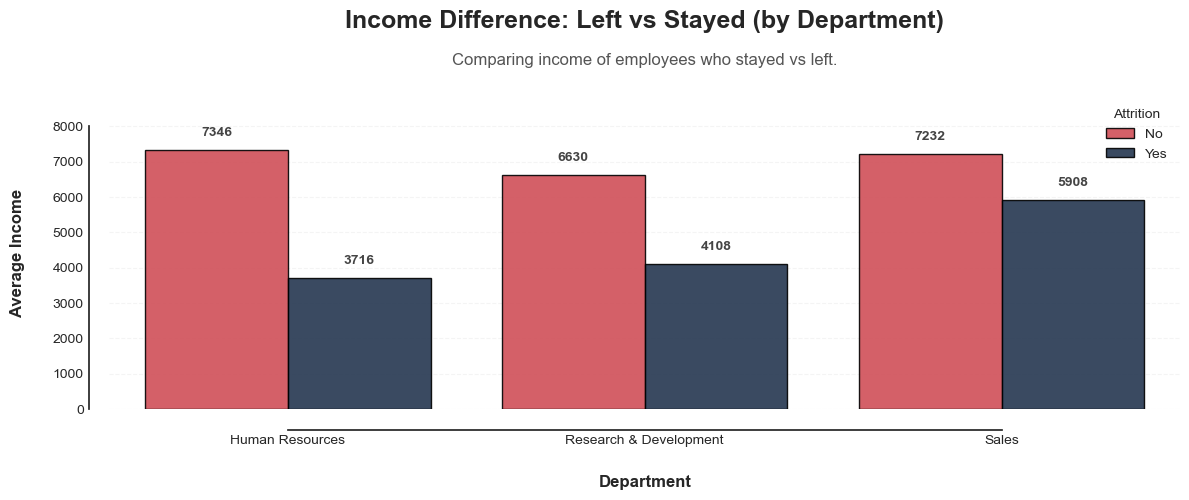

In [29]:
# Log department income vs attrition grouped analysis
logger.info("Creating grouped bar chart: Department income by attrition")

try:
    # Wide figure for grouped bars + legend
    fig, ax = plt.subplots(figsize=(12, 7))

    # Grouped barplot: Income by dept + attrition status
    sns.barplot(
        data=dept_income, 
        x='Department', 
        y='avg_income', 
        hue='Attrition',
        ax=ax,
        palette=['#E63946', '#1D3557'],  # Red=Left, Navy=Stayed (consistent)
        edgecolor='black',
        linewidth=1,
        alpha=0.9
    )

    # Auto data labels on each bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=8, fontsize=10, fontweight='bold', color='#444444')

    # Executive title
    ax.text(x=0.5, y=1.22, s='Income Difference: Left vs Stayed (by Department)', 
            fontsize=18, fontweight='bold', ha='center', transform=ax.transAxes)

    # Key business insight
    ax.text(x=0.5, y=1.10, 
            s='Comparing income of employees who stayed vs left.', 
            fontsize=12, color='#555555', ha='center', transform=ax.transAxes, linespacing=1.6)

    # Professional axes
    ax.set_xlabel('Department', fontsize=12, fontweight='bold', labelpad=20)
    ax.set_ylabel('Average Income', fontsize=12, fontweight='bold', labelpad=20)
    ax.set_ylim(0, dept_income['avg_income'].max() + 1500)

    # Clean legend positioning
    ax.legend(title='Attrition', frameon=False, loc='upper right', bbox_to_anchor=(1, 1))

    # Elegant styling
    sns.despine(ax=ax, offset=15, trim=True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.2)

    # Perfect layout spacing
    fig.tight_layout(rect=[0, 0, 1, 0.80])
    plt.savefig("Income_department_Attrition.png", dpi=300, bbox_inches='tight', facecolor='white')
    
except Exception as e:
    logger.error(f"Visualization failed: {e}")

# Display grouped bar chart
plt.show()

## Income & Department vs Attrition

Across all departments, employees who left the company tend to have lower average income compared to those who stayed.

### What this shows:

- Human Resources: Large income gap between employees who left and stayed  
- Research & Development: Clear but moderate gap  
- Sales: Smaller income gap compared to other departments  

### Key insight:

The impact of income on attrition is not uniform across departments.

- In HR and R&D, lower salary appears to be a strong factor linked to attrition  
- In Sales, the smaller gap suggests that salary alone does not explain why employees leave  

### Deeper interpretation:

Sales already showed high attrition in earlier analysis.

Since the income gap is smaller here, it suggests that:
- other factors like overtime, job pressure, or performance expectations may be stronger drivers in Sales  

### Business implication:

- HR and R&D → focus on compensation-related retention strategies  
- Sales → investigate non-salary factors (overtime, role stress, targets)  

This highlights the need for department-specific retention strategies instead of a one-size-fits-all approach.

In [30]:
# Log marital status vs attrition analysis
logger.info("Analyzing marital status impact on attrition (Single/Married/Divorced)")

try:
    # SQL: Attrition rate by marital status (riskiest first)
    query = """
    SELECT 
        MaritalStatus,
        COUNT(*) AS total_employees,
        SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS employees_left,
        ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS attrition_rate
    FROM hr_attrition
    GROUP BY MaritalStatus
    ORDER BY attrition_rate DESC
    """
    
    # Load marital status breakdown
    marital_attrition = pd.read_sql(query, conn)
    
    
except mysql.connector.Error as e:
    logger.error(f"SQL Error [{e.errno}]: {e}")
except Exception as e:
    logger.error(f"Query failed: {e}")

# Display marital status attrition table
marital_attrition

2026-04-11 01:41:20,967 - INFO - Analyzing marital status impact on attrition (Single/Married/Divorced)


,MaritalStatus,total_employees,employees_left,attrition_rate
0,Single,470,120.0,25.53
1,Married,673,84.0,12.48
2,Divorced,327,33.0,10.09


2026-04-11 01:41:20,984 - INFO - Creating marital status attrition bar chart


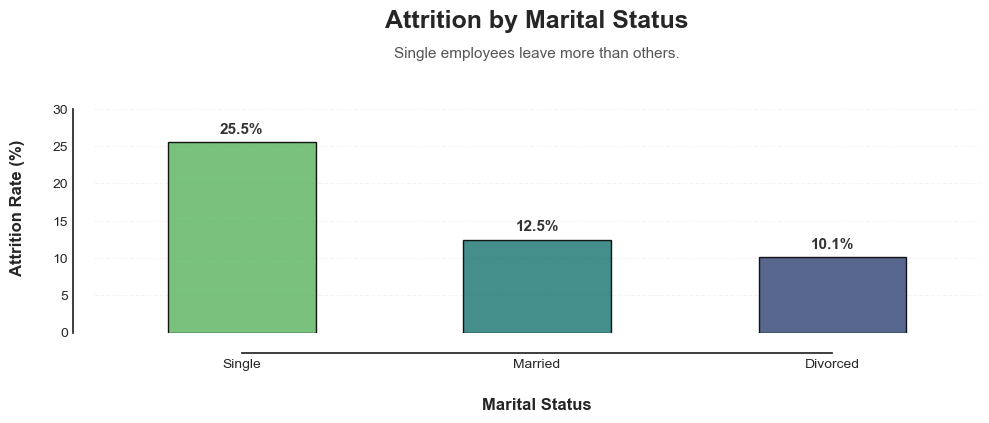

In [31]:
# Log marital status attrition visualization
logger.info("Creating marital status attrition bar chart")

try:
    # Optimized figure for 3 categories
    fig, ax = plt.subplots(figsize=(10, 6))

    # Professional sequential palette
    sns.barplot(
        data=marital_attrition, 
        x='MaritalStatus', 
        y='attrition_rate', 
        ax=ax,
        palette='viridis_r',  # High risk → Low risk gradient
        edgecolor='black',
        linewidth=1,
        width=0.5,
        alpha=0.9
    )

    # Clear % labels above bars
    for i, v in enumerate(marital_attrition['attrition_rate']):
        ax.text(i, v + 1.2, f"{v:.1f}%", ha='center', fontsize=11, fontweight='bold', color='#333333')

    # Executive title with breathing room
    ax.text(x=0.5, y=1.22, s='Attrition by Marital Status', 
            fontsize=18, fontweight='bold', ha='center', transform=ax.transAxes)

    # Demographic insight subtitle
    ax.text(x=0.5, y=1.10, 
            s='Single employees leave more than others.', 
            fontsize=11, color='#555555', ha='center', transform=ax.transAxes, linespacing=1.6)

    # Descriptive axes
    ax.set_xlabel('Marital Status', fontsize=12, fontweight='bold', labelpad=20)
    ax.set_ylabel('Attrition Rate (%)', fontsize=12, fontweight='bold', labelpad=20)
    ax.set_ylim(0, max(marital_attrition['attrition_rate']) + 8)

    # Professional clean styling
    sns.despine(ax=ax, offset=15, trim=True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.2)

    # Perfect layout spacing
    fig.tight_layout(rect=[0, 0, 1, 0.80])
    plt.savefig("Marital_Attrition.png", dpi=300, bbox_inches='tight', facecolor='white')
    
except Exception as e:
    logger.error(f"Visualization failed: {e}")

# Display grouped bar chart
plt.show()            

## Marital Status vs Attrition

Attrition varies across marital status groups.

- Single: ~25.5%  
- Married: ~12.5%  
- Divorced: ~10.1%  

### What this means:

- Single employees leave at roughly 2 times the rate of married or divorced employees  
- This suggests that attrition is higher among employees without long-term attachment to the organization  

### Important consideration:

This pattern may be influenced by age.

Earlier analysis showed that younger employees have higher attrition, and single employees are more likely to fall into this group.

### Key insight:

Marital status appears linked to attrition, but it is likely reflecting underlying factors such as age and career stage rather than being a direct cause.

### Business implication:

Retention strategies should focus more on early-career employees rather than marital status alone.

In [32]:
# Log role–department–overtime risk analysis
logger.info("Analyzing risk profile by JobRole, Department, and OverTime")

try:
    # SQL: High‑risk segments by JobRole, Department, OverTime
    query = """
    SELECT 
        JobRole,
        Department,
        OverTime,
        COUNT(*) AS total_employees,
        SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS employees_left,
        ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS attrition_rate,
        ROUND(AVG(CASE WHEN Attrition = 'Yes' THEN MonthlyIncome END), 2) AS avg_income_leavers,
        ROUND(AVG(CASE WHEN Attrition = 'Yes' THEN JobSatisfaction END), 2) AS avg_satisfaction_leavers
    FROM hr_attrition
    GROUP BY JobRole, Department, OverTime
    HAVING SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) >= 3
    ORDER BY attrition_rate DESC, employees_left DESC
    """
    
    # Load risk profile
    risk_profile = pd.read_sql(query, conn)
    

except mysql.connector.Error as e:
    logger.error(f"SQL Error [{e.errno}]: {e}")
except Exception as e:
    logger.error(f"Query failed: {e}")

# Display risk profile table
risk_profile

2026-04-11 01:41:21,333 - INFO - Analyzing risk profile by JobRole, Department, and OverTime


,JobRole,Department,OverTime,total_employees,employees_left,attrition_rate,avg_income_leavers,avg_satisfaction_leavers
0,Sales Representative,Sales,Yes,24,16.0,66.67,2323.69,2.81
1,Laboratory Technician,Research & Development,Yes,62,31.0,50.00,2971.77,2.61
2,Human Resources,Human Resources,Yes,13,5.0,38.46,3849.40,1.60
3,Research Scientist,Research & Development,Yes,97,33.0,34.02,2645.30,2.55
4,Sales Executive,Sales,Yes,94,31.0,32.98,7609.10,2.65
5,Sales Representative,Sales,No,59,17.0,28.81,2403.35,2.18
6,Manager,Research & Development,Yes,13,3.0,23.08,15106.00,2.00
7,Human Resources,Human Resources,No,39,7.0,17.95,3620.29,2.57
8,Laboratory Technician,Research & Development,No,197,31.0,15.74,2866.74,2.26
9,Sales Executive,Sales,No,232,26.0,11.21,7345.81,2.38


2026-04-11 01:41:21,367 - INFO - Visualizing risk profile as horizontal bar chart


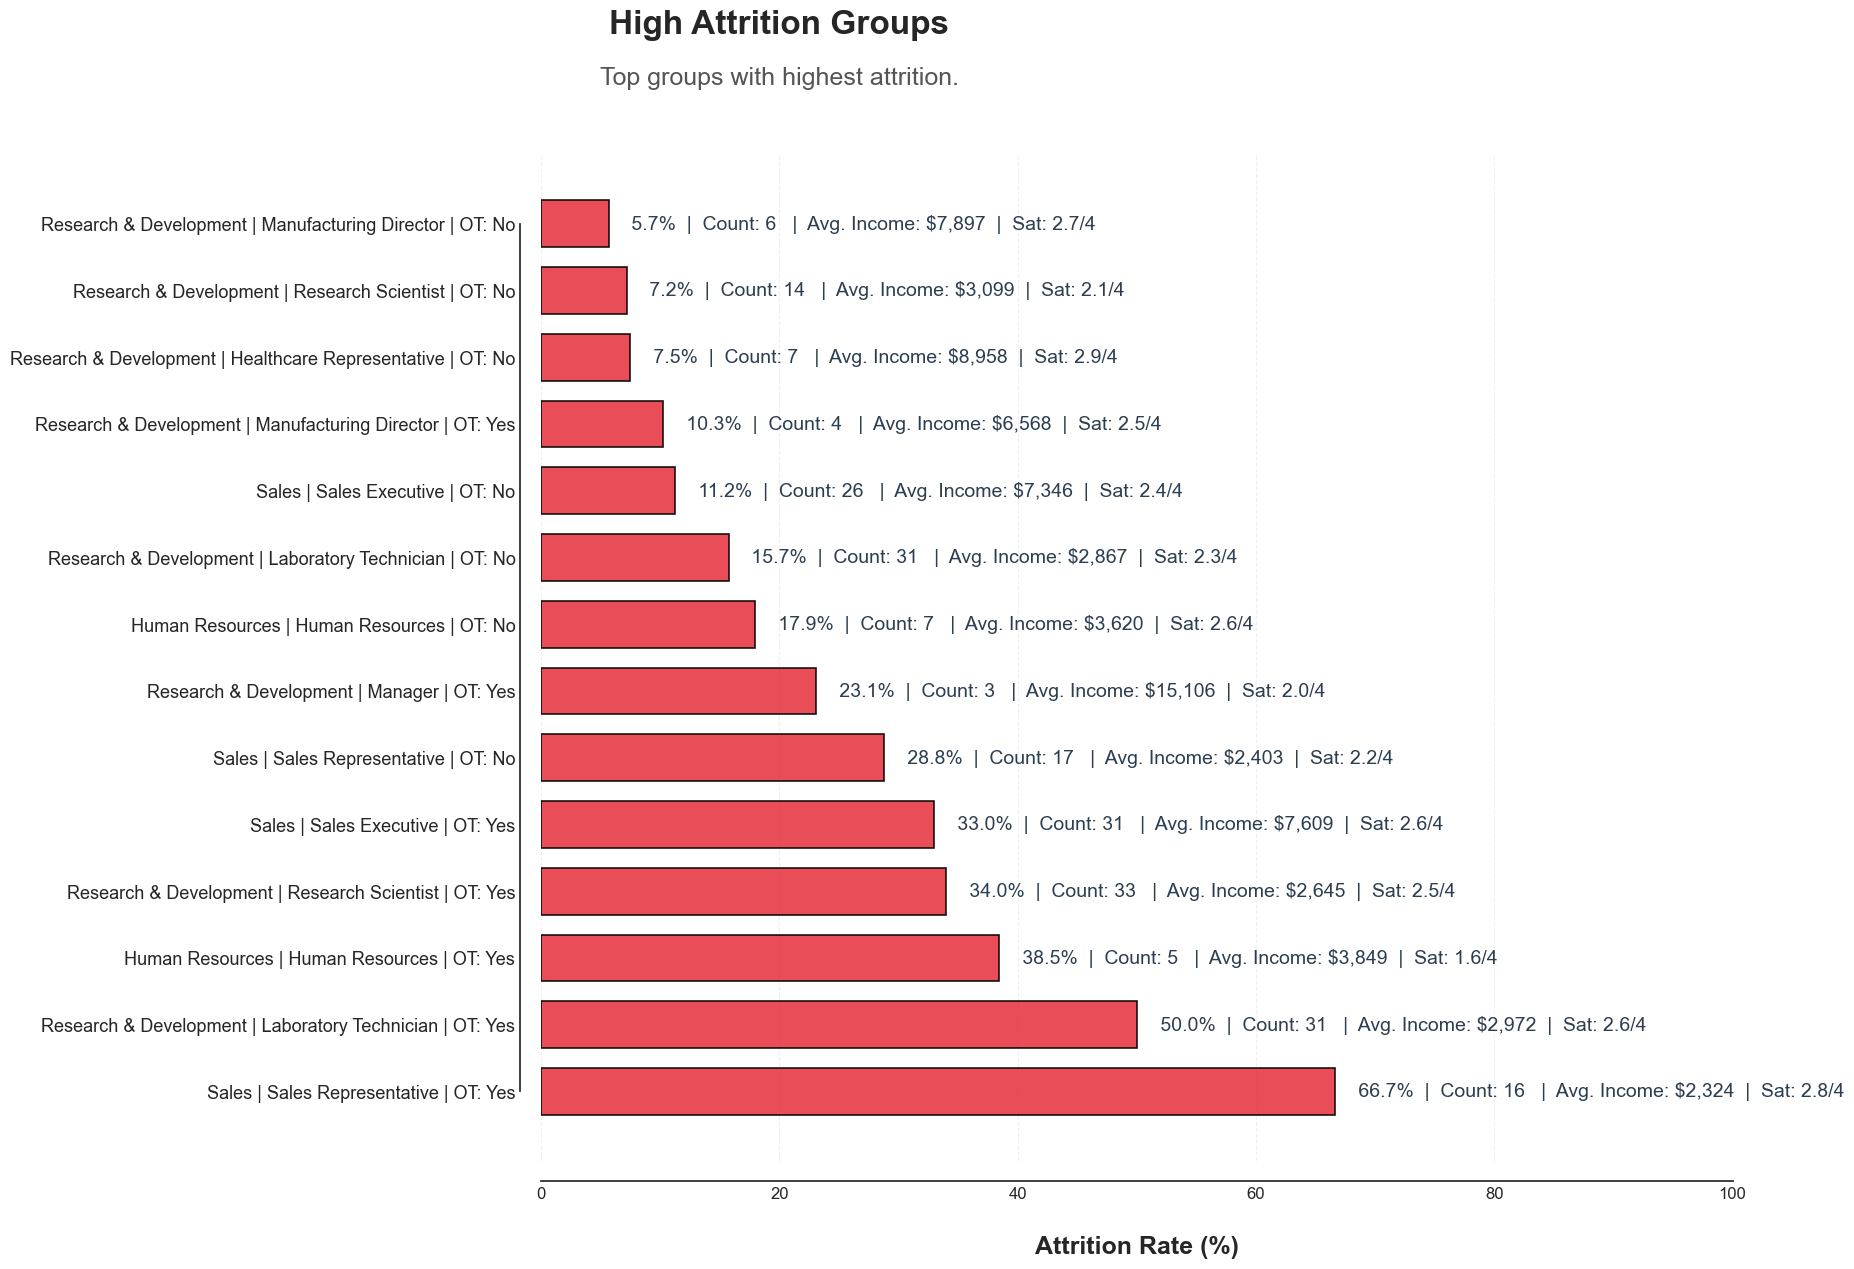

2026-04-11 01:41:22,793 - INFO - Risk profile visualization completed and displayed.


In [33]:
# Log risk profile visualization
logger.info("Visualizing risk profile as horizontal bar chart")

try:
    # Create a descriptive group label for each segment
    risk_profile["Group"] = (
        risk_profile["Department"]
        + " | "
        + risk_profile["JobRole"]
        + " | OT: "
        + risk_profile["OverTime"]
    )

    # 1. Use taller figure (18, 14) to let the bars breathe
    fig, ax1 = plt.subplots(figsize=(18, 14))

    # 2. Horizontal bar plot with chunky, premium styling
    bars = ax1.barh(
        risk_profile["Group"],
        risk_profile["attrition_rate"],
        color="#E63946",
        alpha=0.9,
        edgecolor="black",
        linewidth=1.2,
        height=0.7,
    )

    # 3. Larger, rich data labels on each bar
    for i, (rate, count, income, sat) in enumerate(
        zip(
            risk_profile["attrition_rate"],
            risk_profile["employees_left"],
            risk_profile["avg_income_leavers"],
            risk_profile["avg_satisfaction_leavers"],
        )
    ):
        label_text = (
            f" {rate:.1f}%  |  Count: {int(count)}  "
            f" |  Avg. Income: ${income:,.0f}  |  Sat: {sat:.1f}/4"
        )
        ax1.text(
            rate + 1.5,
            i,
            label_text,
            va="center",
            fontsize=14,
            fontweight="500",
            color="#2C3E50",
        )

    # 4. Large, centered title and subtitle
    ax1.text(
        x=0.2,
        y=1.12,
        s="High Attrition Groups",
        fontsize=24,
        fontweight="bold",
        ha="center",
        transform=ax1.transAxes,
    )

    ax1.text(
        x=0.2,
        y=1.07,
        s="Top groups with highest attrition.",
        fontsize=18,
        color="#555555",
        ha="center",
        transform=ax1.transAxes,
        linespacing=1.6,
    )

    # 5. Axis refinement and labels
    ax1.set_xlabel("Attrition Rate (%)", fontsize=18, fontweight="bold", labelpad=25)
    ax1.set_xlim(0, 100)
    ax1.tick_params(axis="y", labelsize=13)
    ax1.tick_params(axis="x", labelsize=12)

    # 6. Clean styling and grid
    sns.despine(ax=ax1, offset=15, trim=True)
    ax1.xaxis.grid(True, linestyle="--", alpha=0.3)

    # 7. Adjust layout for large titles
    fig.tight_layout(rect=[0, 0, 1, 0.92])

    plt.savefig(
        "Comprehensive_Risk_Profile_Large.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.show()

    logger.info("Risk profile visualization completed and displayed.")

except Exception as e:
    logger.error(f"Failed to create risk profile chart: {e}")

## Multi-Factor Attrition Risk Analysis

When multiple risk factors are combined, attrition becomes extremely concentrated in specific employee groups.

### Highest-risk segments:

- Sales Representatives working overtime → ~66.7% attrition  
- Laboratory Technicians working overtime → ~50% attrition  
- HR roles with overtime also show elevated attrition (~38%+)  

### What this means:

- Overtime is the most consistent and dominant risk factor  
- Its impact becomes much stronger when combined with certain job roles  
- Income also plays a role, as many high-risk groups fall in lower salary ranges  
- Job satisfaction appears to support the trend but is not the primary driver  

### Key insight:

Attrition is not random — it is highly concentrated in specific combinations of factors.

The most critical pattern is:
→ Operational roles + Overtime + Lower income = highest attrition risk  

### Business implication:

- Sales and operational roles working overtime should be the top priority for retention  
- Reducing overtime or managing workload in these roles could significantly lower attrition  
- A targeted approach is required — broad policies will not be effective  

This is the strongest signal in the analysis and should guide decision-making.

---

# Phase 2: Python-Driven Analysis

In this section, I used **Python (Pandas, Seaborn, SciPy)** to go deeper — encoding features, building a correlation matrix, running group-by comparisons, and validating findings with a statistical t-test.

---

In [34]:
# Log data encoding step
logger.info("Starting categorical encoding for machine‑learning features")

try:
    # Step 1: Create a copy of the original DataFrame
    df_encoded = df.copy()
    logger.info("Created copy 'df_encoded' for feature encoding.")

    # Step 2: Manually encode binary categorical columns to 0/1
    df_encoded["Attrition"] = df_encoded["Attrition"].map(
        {"Yes": 1, "No": 0}
    )

    df_encoded["OverTime"] = df_encoded["OverTime"].map(
        {"Yes": 1, "No": 0}
    )

    df_encoded["Gender"] = df_encoded["Gender"].map(
        {"Male": 1, "Female": 0}
    )

    # Step 3: Drop non‑numeric columns that cannot be simply encoded
    cols_to_drop = [
        "BusinessTravel",
        "Department",
        "EducationField",
        "JobRole",
        "MaritalStatus",
    ]
    df_encoded = df_encoded.drop(columns=cols_to_drop)

    print(f"Encoded DataFrame: {df_encoded.shape[0]} rows, {df_encoded.shape[1]} columns")

except KeyError as e:
    logger.error(f"Column missing during encoding: {e}")
except Exception as e:
    logger.error(f"Failed during categorical encoding: {e}")

# Display encoded DataFrame head
df_encoded.head()

2026-04-11 01:41:22,801 - INFO - Starting categorical encoding for machine‑learning features
2026-04-11 01:41:22,802 - INFO - Created copy 'df_encoded' for feature encoding.


Encoded DataFrame: 1470 rows, 27 columns


,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,1102,1,2,1,2,0,94,3,...,3,1,0,8,0,1,6,4,0,5
1,49,0,279,8,1,2,3,1,61,2,...,4,4,1,10,3,3,10,7,1,7
2,37,1,1373,2,2,4,4,1,92,2,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1392,3,4,5,4,0,56,3,...,3,3,0,8,3,3,8,7,3,0
4,27,0,591,2,1,7,1,1,40,3,...,3,4,1,6,3,3,2,2,2,2


2026-04-11 01:41:22,823 - INFO - Generating strategic correlation matrix heatmap
2026-04-11 01:41:23,311 - INFO - Saving high‑visibility correlation matrix to 'Correlation_Matrix_HighVis.png'


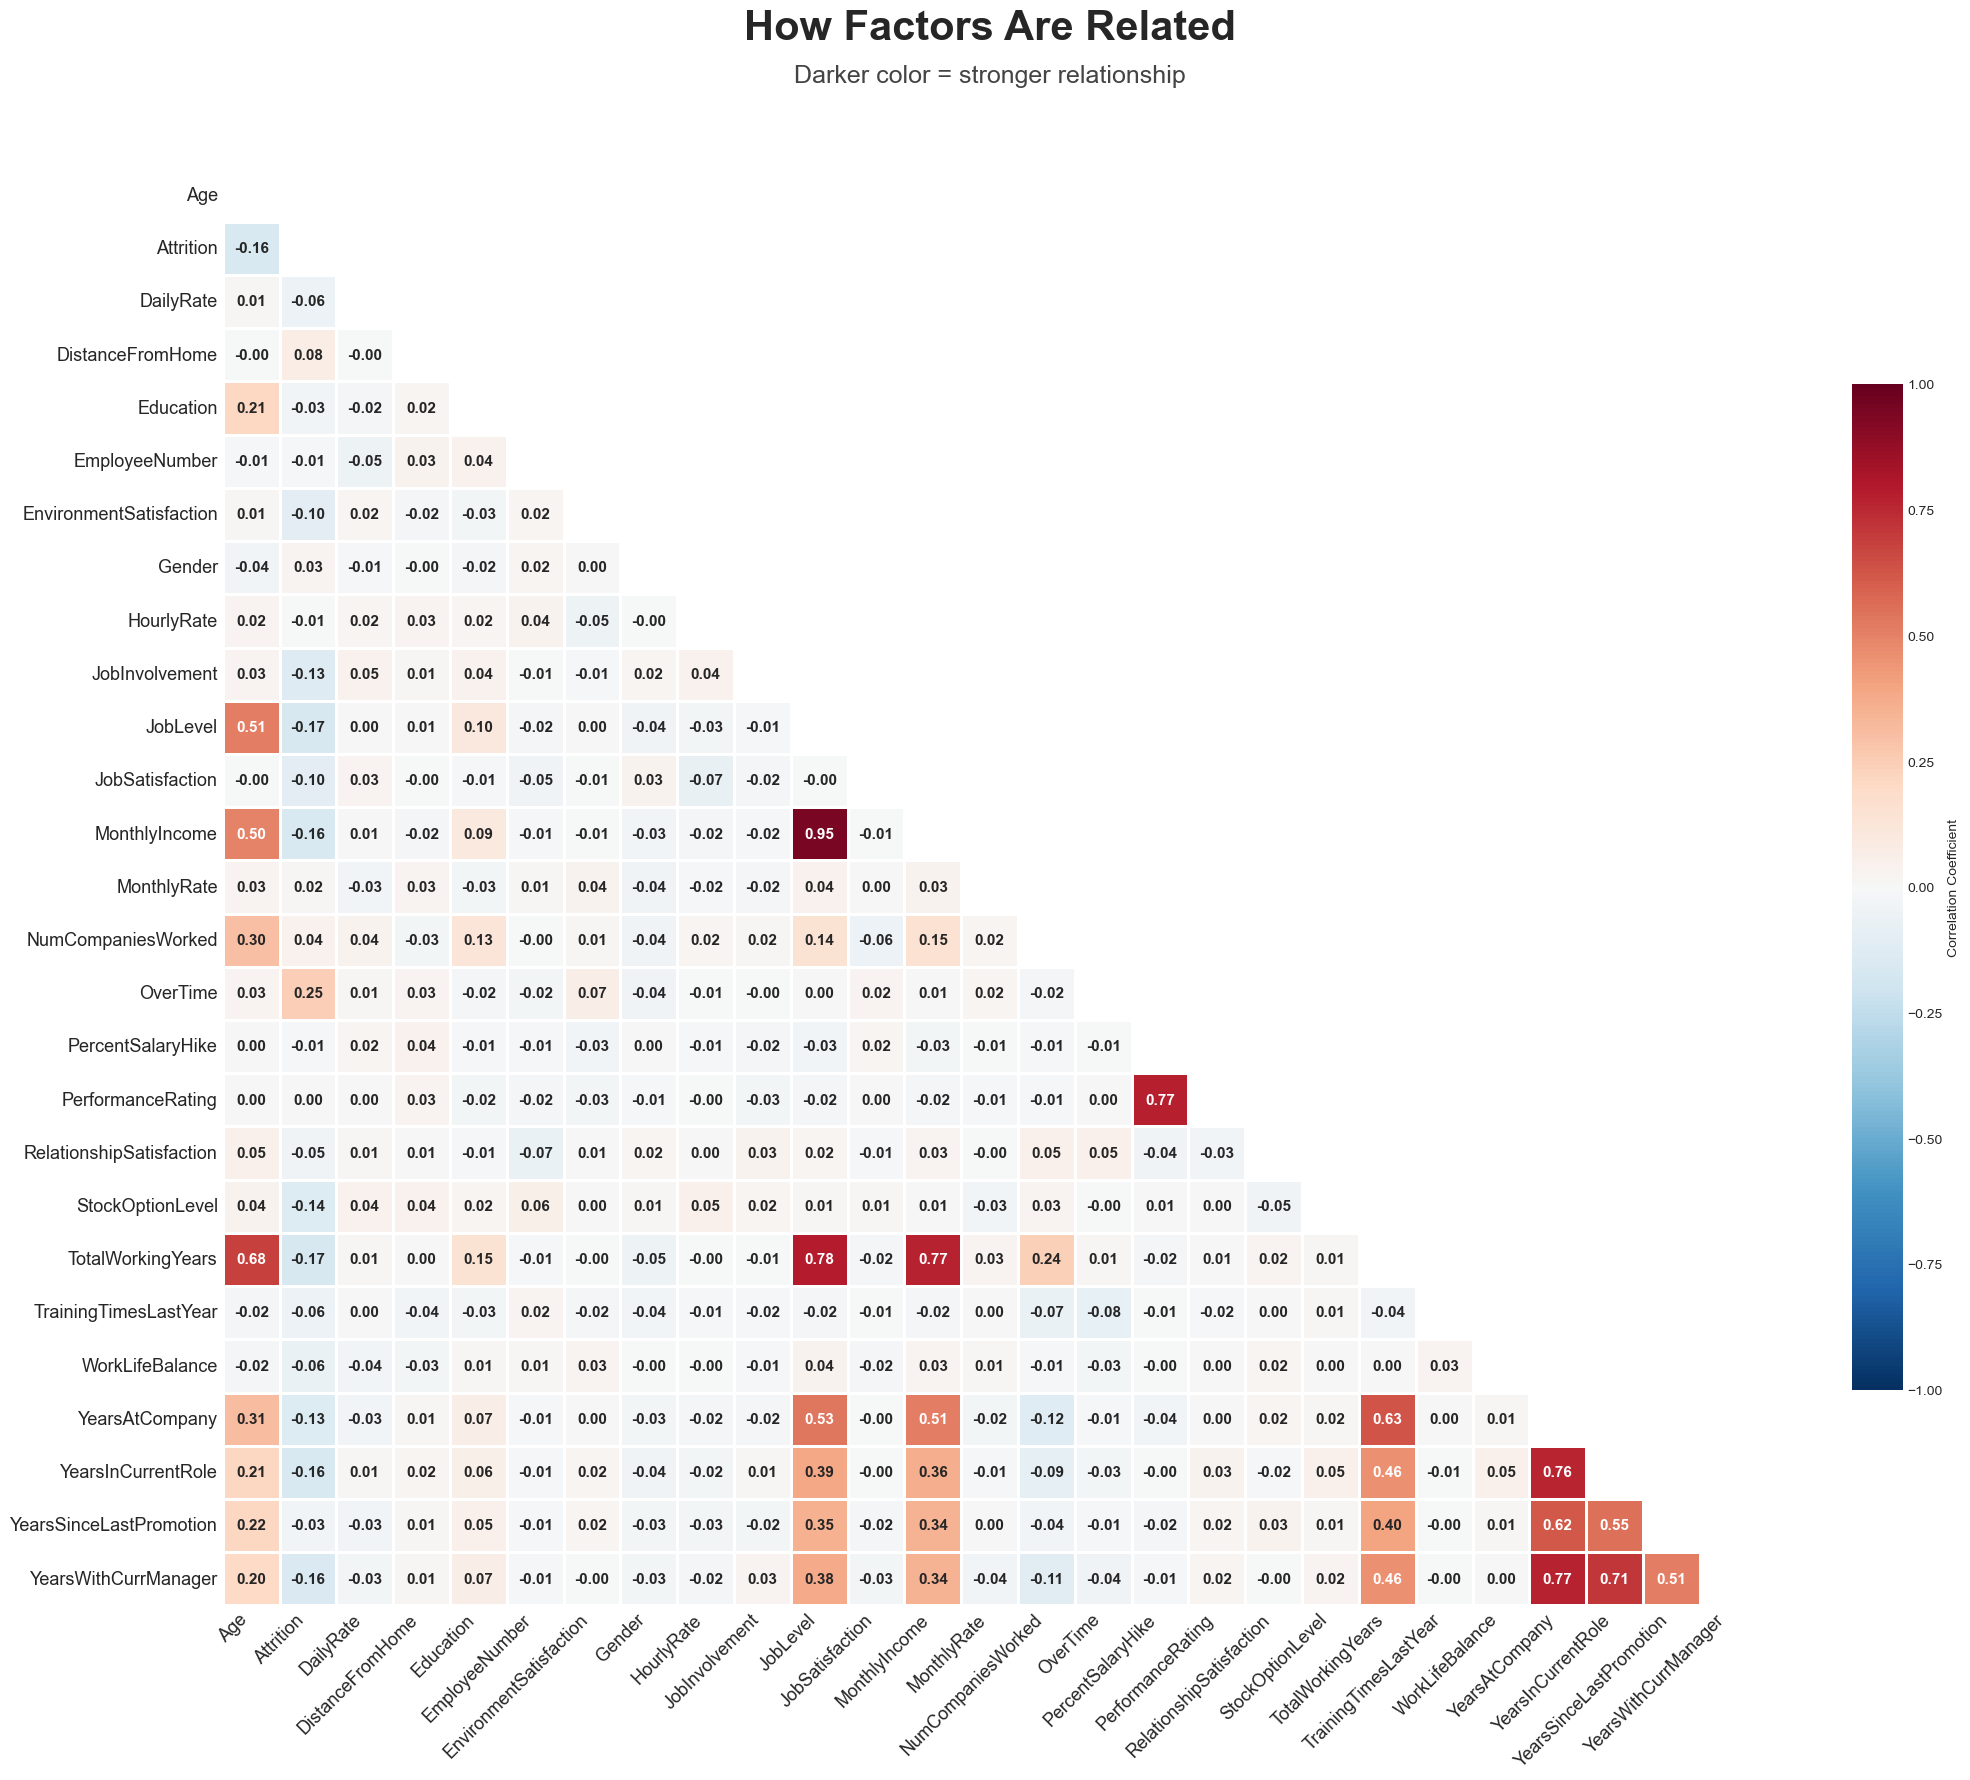

2026-04-11 01:41:25,838 - INFO - Correlation matrix visualization completed and displayed.


In [35]:
# Log correlation matrix visualization
logger.info("Generating strategic correlation matrix heatmap")

try:
    # 1. Extreme scale: (24, 20) ensures cells are large enough to read
    fig, ax = plt.subplots(figsize=(24, 20))

    # Compute correlation matrix
    correlation = df_encoded.corr()
    mask = np.triu(np.ones_like(correlation, dtype=bool))

    # 2. Create the heatmap
    # 'annot=True' with larger font; if too crowded, use '(correlation.abs() > 0.1)' idea
    sns.heatmap(
        correlation,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        linewidths=0.8,
        annot_kws={"size": 11, "fontweight": "bold"},  # Increased from default
        vmin=-1,
        vmax=1,
        ax=ax,
        cbar_kws={"shrink": 0.7, "label": "Correlation Coefficient"},
    )

    # 3. Add large, centered header
    ax.text(
        x=0.5,
        y=1.09,
        s="How Factors Are Related",
        fontsize=30,
        fontweight="bold",
        ha="center",
        transform=ax.transAxes,
    )

    ax.text(
        x=0.5,
        y=1.06,
        s="Darker color = stronger relationship",
        fontsize=18,
        color="#444444",
        ha="center",
        transform=ax.transAxes,
        linespacing=1.6,
    )

    # 4. Axis labels: big and clean
    ax.tick_params(axis="both", which="major", labelsize=13)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    # 5. Precise spacing and layout
    fig.tight_layout(rect=[0, 0, 0.9, 0.90])

    # 6. Save high‑clarity image
    logger.info("Saving high‑visibility correlation matrix to 'Correlation_Matrix_HighVis.png'")
    plt.savefig(
        "Correlation_Matrix_HighVis.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    logger.info("Correlation matrix visualization completed and displayed.")

except Exception as e:
    logger.error(f"Failed to generate correlation matrix heatmap: {e}")

## Correlation Analysis

Most factors don’t show a strong direct link with attrition. This means no single variable alone can explain why employees leave.

Some strong relationships do appear between related fields, like:
- salary and job level  
- different experience-related columns  

These are expected because they naturally move together.

### What this means:

Attrition is not driven by one factor.  
- It is a result of multiple things coming together — like role, overtime, income, and experience.

So instead of looking at one variable in isolation, we need to focus on combinations of factors to understand why employees leave.

In [36]:
# Log top features correlated with Attrition
logger.info("Extracting top features correlated with Attrition (positive and negative)")

try:
    # Top features correlated with Attrition (positive and negative)
    attrition_corr = correlation["Attrition"].drop("Attrition").sort_values(key=abs, ascending=False)

    # Log the top 10
    top_10 = attrition_corr.head(10)

    # Print to console in your notebook
    print("Top 10 features correlated with Attrition:\n")
    print(top_10.to_string())

except KeyError as e:
    logger.error(f"Column not found in correlation matrix: {e}")
except Exception as e:
    logger.error(f"Failed to extract top features correlated with Attrition: {e}")

2026-04-11 01:41:25,845 - INFO - Extracting top features correlated with Attrition (positive and negative)


Top 10 features correlated with Attrition:

OverTime                0.246118
TotalWorkingYears      -0.171063
JobLevel               -0.169105
YearsInCurrentRole     -0.160545
MonthlyIncome          -0.159840
Age                    -0.159205
YearsWithCurrManager   -0.156199
StockOptionLevel       -0.137145
YearsAtCompany         -0.134392
JobInvolvement         -0.130016


In [37]:
try:
    # Group‑by: compute median income and various satisfaction metrics by Attrition
    group_analysis = df_encoded.groupby(["Attrition"]).agg(
        median_income=("MonthlyIncome", "median"),
        mean_satisfaction=("JobSatisfaction", "mean"),
        mean_work_life=("WorkLifeBalance", "mean"),
        mean_env_satisfaction=("EnvironmentSatisfaction", "mean"),
        mean_years=("YearsAtCompany", "median"),
        count=("MonthlyIncome", "count"),
    ).reset_index()

    # Replace numeric Attrition back to human labels
    group_analysis["Attrition"] = group_analysis["Attrition"].map({1: "Left", 0: "Stayed"})
    logger.info("Group‑by analysis completed and 'Attrition' labels mapped to 'Left'/'Stayed'.")

except KeyError as e:
    logger.error(f"Missing column during group‑by aggregations: {e}")
except Exception as e:
    logger.error(f"Failed during group‑by Attrition analysis: {e}")

# Display the group_analysis DataFrame (in Jupyter, this is the last line)
group_analysis

2026-04-11 01:41:25,853 - INFO - Group‑by analysis completed and 'Attrition' labels mapped to 'Left'/'Stayed'.


,Attrition,median_income,mean_satisfaction,mean_work_life,mean_env_satisfaction,mean_years,count
0,Stayed,5204.0,2.778589,2.781022,2.771290,6.0,1233
1,Left,3202.0,2.468354,2.658228,2.464135,3.0,237


## Key Observation: Attrition is Not Simple

Most factors on their own don’t show a strong connection with attrition. This means employees are not leaving because of just one reason. In most cases, it’s a combination of things like workload, salary, role, and experience.

---

## Key Point

Attrition doesn’t have a single cause. To understand and fix it, we need to look at how multiple factors come together, instead of trying to find one main reason.

In [38]:
# Log independent‑samples t‑test: income vs attrition
logger.info("Running independent‑samples t‑test on MonthlyIncome by Attrition (Left vs Stayed)")

try:
    # Split income by attrition status
    left = df[df["Attrition"] == "Yes"]["MonthlyIncome"]
    stayed = df[df["Attrition"] == "No"]["MonthlyIncome"]

    # Run independent samples t‑test
    t_stat, p_value = stats.ttest_ind(left, stayed)
    
    # ───── BEAUTIFIED, REPORT‑STYLE OUTPUT ─────

    # Header
    print("\n" + "═" * 80)
    print("                       INCOME & ATTRITION: TWO‑SAMPLE T‑TEST")
    print("═" * 80)

    # Group statistics
    print(f"Employees who left  → Median income:  {left.median():,.0f}")
    print(f"                      Mean income:      {left.mean():,.2f}")
    print(f"                      Count (n):        {len(left):,}")
    print()

    print(f"Employees who stayed → Median income:  {stayed.median():,.0f}")
    print(f"                       Mean income:      {stayed.mean():,.2f}")
    print(f"                       Count (n):        {len(stayed):,}")

    # Line separator
    print("\n" + "─" * 50)

    # Test results
    print("STATISTICAL TEST RESULTS")
    print("─" * 50)
    print(f"T-statistic (t)        : {t_stat:10.4f}")
    print(f"P-value (two‑sided)    : {p_value:10.6f}")

    # Interpretation with emphasis
    print("\n" + "─" * 50)
    if p_value < 0.05:
        print("SIGNIFICANCE: YES (p < 0.05)")
        print("Lower pay is strongly associated with attrition in this dataset.")
    else:
        print("SIGNIFICANCE: NO (p >= 0.05)")
        print("No statistically significant income difference between leavers and stayers.")

except KeyError as e:
    logger.error(f"Missing column during income t‑test: {e}")
except Exception as e:
    logger.error(f"Failed during t‑test on MonthlyIncome by Attrition: {e}")

2026-04-11 01:41:25,878 - INFO - Running independent‑samples t‑test on MonthlyIncome by Attrition (Left vs Stayed)



════════════════════════════════════════════════════════════════════════════════
                       INCOME & ATTRITION: TWO‑SAMPLE T‑TEST
════════════════════════════════════════════════════════════════════════════════
Employees who left  → Median income:  3,202
                      Mean income:      4,787.09
                      Count (n):        237

Employees who stayed → Median income:  5,204
                       Mean income:      6,832.74
                       Count (n):        1,233

──────────────────────────────────────────────────
STATISTICAL TEST RESULTS
──────────────────────────────────────────────────
T-statistic (t)        :    -6.2039
P-value (two‑sided)    :   0.000000

──────────────────────────────────────────────────
SIGNIFICANCE: YES (p < 0.05)
Lower pay is strongly associated with attrition in this dataset.


## Income vs Attrition (T-Test)

I wanted to check if the income difference between employees who left and those who stayed is actually real, or just random.

So I ran a simple t-test.

### What I found:

- Employees who left earn around **4,787** on average  
- Employees who stayed earn around **6,833** on average  

That’s a gap of about **2,000**, which is quite noticeable.

### Test result:

- t-statistic: -6.20  
- p-value: almost 0  

### What this tells us:

This difference is not happening by chance.Employees who leave the company are generally earning less.

### One important thing:

This doesn’t mean salary is the only reason people leave.It just shows that income is one of the factors. From earlier analysis, things like overtime, role, and experience also play a big role.

In [39]:
def analyze_risk_stats(risk_profile):
    logger.info("🔬 Running statistical analysis on our risk_profile...")
    
    # Copy data
    stats_df = risk_profile.copy()
    
    # ── ASSUMPTIONS & OVERALL RATE ──
    overall_rate = stats_df['attrition_rate'].mean()
    min_sample = 30  # Reliable sample size
    
    # ── ADD STATISTICAL COLUMNS ──
    for idx, row in stats_df.iterrows():
        sample_size = row['total_employees']
        
        # Risk multiplier vs company average
        stats_df.at[idx, 'risk_multiplier'] = round(row['attrition_rate'] / overall_rate, 2)
        
        # Sample reliability
        stats_df.at[idx, 'reliable_sample'] = sample_size >= min_sample
        
        # Business risk level
        rate = row['attrition_rate']
        if rate >= 50:
            stats_df.at[idx, 'business_risk'] = 'CRITICAL'
        elif rate >= 30:
            stats_df.at[idx, 'business_risk'] = 'HIGH RISK'
        elif rate >= 20:
            stats_df.at[idx, 'business_risk'] = 'WARNING'
        else:
            stats_df.at[idx, 'business_risk'] = 'LOW RISK'
        
        # Priority score (rate + sample size + income factor)
        priority = (rate / 100) * 50 + (1 if sample_size >= 50 else 0) * 20 + (50/row['avg_income_leavers']) * 30
        stats_df.at[idx, 'priority_score'] = round(priority, 1)
    
    # ── CHI-SQUARE FOR EACH SEGMENT ──
    for idx, row in stats_df.iterrows():
        expected_left = row['total_employees'] * (overall_rate / 100)
        observed_left = row['employees_left']
        
        # Quick chi-square test
        chi2, p_value, _, _ = stats.chi2_contingency([
            [observed_left, row['total_employees'] - observed_left],
            [stats_df['employees_left'].sum() - observed_left, 
             stats_df['total_employees'].sum() - row['total_employees']]
        ])
        
        stats_df.at[idx, 'p_value'] = round(p_value, 4)
        stats_df.at[idx, 'significant'] = p_value < 0.05
    
    # ── SORT BY PRIORITY ──
    stats_df = stats_df.sort_values('priority_score', ascending=False).reset_index(drop=True)
    
    
    return stats_df[['JobRole', 'Department', 'OverTime', 'total_employees', 'employees_left', 
                     'attrition_rate', 'business_risk', 'priority_score', 'p_value', 'significant']]

# ── RUN IT NOW ──
risk_stats = analyze_risk_stats(risk_profile)
risk_stats.head(10).round(2)

2026-04-11 01:41:25,894 - INFO - 🔬 Running statistical analysis on our risk_profile...


,JobRole,Department,OverTime,total_employees,employees_left,attrition_rate,business_risk,priority_score,p_value,significant
0,Laboratory Technician,Research & Development,Yes,62,31.0,50.00,CRITICAL,45.5,0.00,True
1,Research Scientist,Research & Development,Yes,97,33.0,34.02,HIGH RISK,37.6,0.00,True
2,Sales Executive,Sales,Yes,94,31.0,32.98,HIGH RISK,36.7,0.00,True
3,Sales Representative,Sales,No,59,17.0,28.81,WARNING,35.0,0.01,True
4,Sales Representative,Sales,Yes,24,16.0,66.67,CRITICAL,34.0,0.00,True
5,Laboratory Technician,Research & Development,No,197,31.0,15.74,LOW RISK,28.4,1.00,False
6,Sales Executive,Sales,No,232,26.0,11.21,LOW RISK,25.8,0.05,True
7,Research Scientist,Research & Development,No,195,14.0,7.18,LOW RISK,24.1,0.00,True
8,Healthcare Representative,Research & Development,No,94,7.0,7.45,LOW RISK,23.9,0.04,True
9,Manufacturing Director,Research & Development,No,106,6.0,5.66,LOW RISK,23.0,0.01,True


## Advanced Risk Profiling

After combining role, department, and overtime, some clear high-risk groups stand out.

### Highest-risk groups:

- Sales Representatives working overtime → **66.7% attrition**  
- Laboratory Technicians working overtime → **50% attrition**  
- Research Scientists working overtime → **34% attrition**  

These are not small differences — these are major problem areas.

---

## What stands out

### 1. Overtime makes a huge difference

The same role behaves very differently depending on overtime.

- Laboratory Technicians (Overtime) → **50% attrition**  
- Laboratory Technicians (No Overtime) → **~16% attrition**

That’s a massive jump just because of workload.

---

### 2. Some roles are much more sensitive

Sales roles and operational roles react much more strongly to overtime.

Sales Representatives with overtime are the worst case:
→ **2 out of 3 employees are leaving**

---

### 3. This is not random

The high-risk groups consistently show very low p-values, which means these patterns are real and not just noise in the data.

---

## What this means for the business

- Overtime is the biggest driver of attrition in this dataset  
- Its impact becomes much worse in certain roles (especially Sales and operational roles)  
- Salary and satisfaction matter, but they are not as strong as workload in these high-risk groups  

---

## Key takeaway

Attrition is not spread evenly across the company. It is concentrated in specific combinations:

→ **Role + Overtime = Highest Risk**

If the company wants to reduce attrition, the first place to act is:
- Sales teams with high workload  
- Laboratory and operational roles with overtime

2026-04-11 01:41:25,932 - INFO - Creating TOP 12 risk priority bar chart...


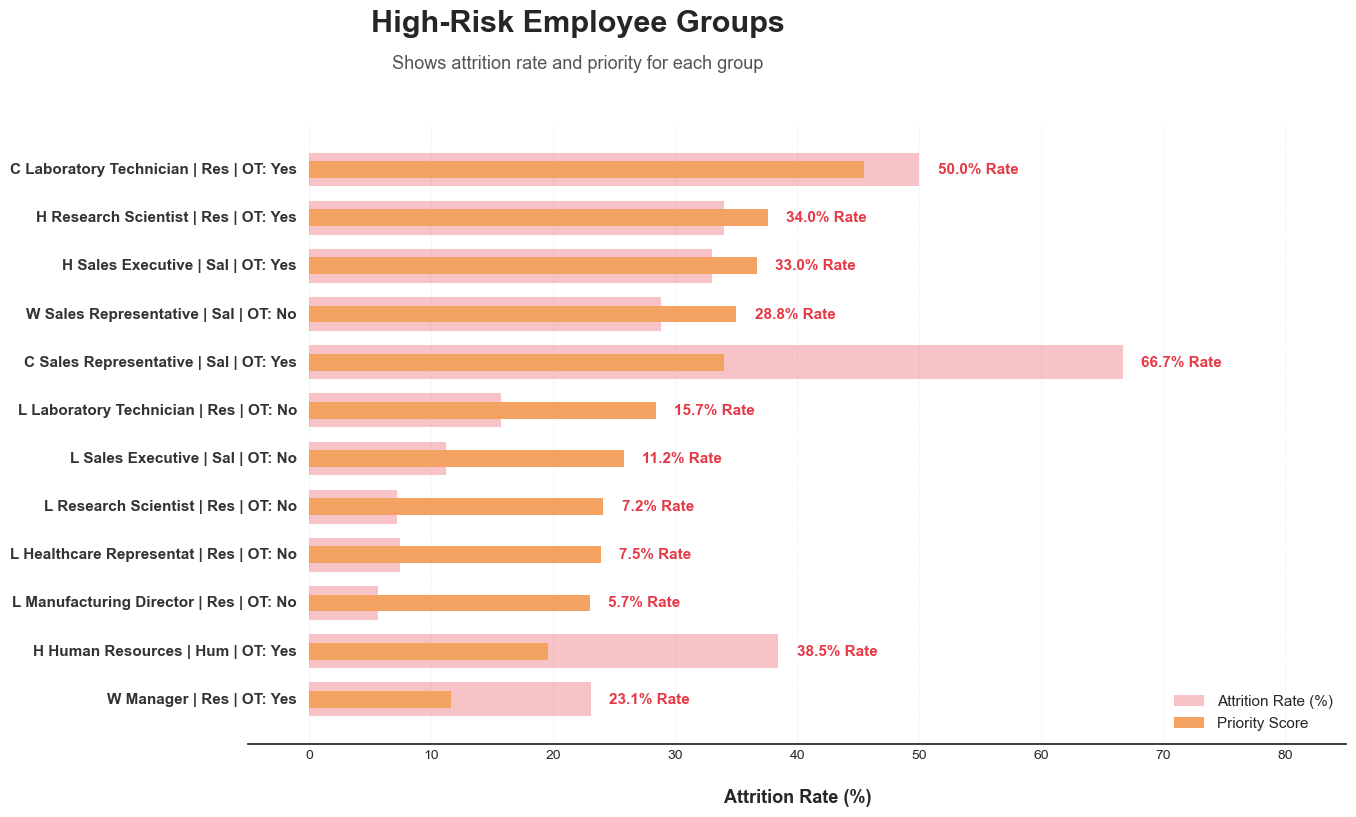

2026-04-11 01:41:26,697 - INFO - TOP Risk Priority Bars saved!


In [40]:
def plot_risk_priority_bars(risk_stats, top_n=12):
    """Horizontal bars: rate + priority score + risk emoji"""
    logger.info(f"Creating TOP {top_n} risk priority bar chart...")
    
    # Sort by priority to make the visual flow better
    top_risks = risk_stats.sort_values('priority_score', ascending=True).tail(top_n)
    
    fig, ax = plt.subplots(figsize=(16, 10), facecolor='white')
    
    y_pos = range(len(top_risks))
    
    # 1. Background Bar: Attrition Rate (Thick)
    ax.barh(y_pos, top_risks['attrition_rate'], 
            color='#E63946', alpha=0.3, label='Attrition Rate (%)', height=0.7)
    
    # 2. Foreground Bar: Priority Score (Thin & Solid)
    # This creates a sophisticated "bullet" look
    bars = ax.barh(y_pos, top_risks['priority_score'], 
                   color='#F4A261', alpha=1.0, label='Priority Score', height=0.35)
    
    # 3. Enhanced Labeling
    for i, row in enumerate(top_risks.itertuples()):
        # Segment Info on the left side
        risk_emoji = row.business_risk[0] 
        group_label = f"{risk_emoji} {row.JobRole[:22]} | {row.Department[:3]} | OT: {row.OverTime}"
        
        # Placing label inside or at the start of the axis for readability
        ax.text(-1, i, group_label, va='center', ha='right', 
                fontsize=11, fontweight='bold', color='#333333')
        
        # Data value at the end of the bar
        ax.text(max(row.attrition_rate, row.priority_score) + 1.5, i, 
                f"{row.attrition_rate:.1f}% Rate", 
                va='center', fontsize=11, fontweight='bold', color='#E63946')

    # 4. Centered Title and Subtitle
    ax.text(x=0.3, y=1.15, s='High-Risk Employee Groups', 
            fontsize=22, fontweight='bold', ha='center', transform=ax.transAxes)
    
    ax.text(x=0.3, y=1.09, 
            s='Shows attrition rate and priority for each group', 
            fontsize=13, color='#555555', ha='center', transform=ax.transAxes, linespacing=1.6)

    # 5. Axis & Styling
    ax.set_yticks([]) # Hide the default y-ticks as we have custom labels
    ax.set_xlabel('Attrition Rate (%)', fontsize=13, fontweight='bold', labelpad=20)
    ax.set_xlim(-5, 85) # Provide extra space for the labels on left and right
    
    # Custom Legend
    ax.legend(loc='lower right', frameon=False, fontsize=11)
    
    # Modern finish: Remove borders
    sns.despine(ax=ax, left=True, bottom=False)
    ax.xaxis.grid(True, linestyle='--', alpha=0.2)

    # Final Spacing
    fig.tight_layout(rect=[0.15, 0, 1, 0.85])
    
    plt.savefig('TopRiskPriorityBars_Premium.png', dpi=300, bbox_inches='tight')
    plt.show()
    logger.info("TOP Risk Priority Bars saved!")

# RUN IT
plot_risk_priority_bars(risk_stats, top_n=12)

## Interpretation

Some groups clearly stand out with very high attrition.

- Sales Representatives working overtime → **66.7% attrition**  
- Laboratory Technicians working overtime → **50% attrition**  
- Research Scientists working overtime → **34% attrition**  

These are not small increases — these are extremely high levels.A key pattern is that the same roles behave very differently depending on overtime.

For example:
- Laboratory Technicians (Overtime) → ~50%  
- Laboratory Technicians (No Overtime) → ~16%  

This shows how much workload is changing the outcome.

---

## Key Insights

- Overtime is the strongest driver across almost all high-risk groups  
- Its impact becomes much worse in Sales and operational roles  
- Some roles are stable without overtime, but become high-risk when overtime is added  

---

## Key Point

The biggest problem is not just the role — it is the combination:

→ **Role + Overtime**

To reduce attrition, the company should focus first on:
- Sales teams with high workload  
- Laboratory and operational roles working overtime

# Final Summary & Recommendations

---

## What the Data Shows

Out of 1,470 employees, **237 left (16.12%)**. This is not random. Certain groups are clearly more likely to leave than others.

---

## What is driving attrition

- **Overtime** → biggest impact  
  People working overtime leave almost **3x more** (30.5% vs 10.4%)

- **Income** → clear gap  
  Employees who left earn much less (~4,787 vs ~6,833)

- **Age** → early career risk  
  18–25 group has the highest attrition (**35.8%**)

- **Job Role** → some roles are much worse  
  Sales Representatives → **39.8% attrition**

- **Tenure** → people leave early  
  Leavers ~5 years vs stayed ~7.4 years

- **Marital Status** → likely linked to age  
  Singles leave more (**25.5%**), but this is probably an age effect

- **Job Satisfaction** → low satisfaction matters  
  Level 1 → **22.8%**, Level 4 → **11.3%**

---

## Where the real problem is

The risk is not from one factor.It shows up when multiple things come together.

High-risk employees usually are:
- working overtime  
- earning less  
- in roles like Sales or Lab Tech  
- early in their career  
- not very satisfied  

Worst case:
→ **Sales Representatives with overtime → 66.7% attrition**

That’s extremely high.

---

## What should be done

1. **Reduce overtime first**  
- This is the biggest problem, especially in Sales and operational roles  

2. **Fix pay where it actually matters**  
- Not everywhere — focus on roles where low income and attrition overlap  

3. **Focus on early-career employees**  
- Most people leave in the first few years  

4. **Pay attention to younger employees**  
- They are leaving at more than double the average  

5. **Catch dissatisfaction early**  
- People don’t leave when they’re “okay” — they leave when they’re unhappy  

---

## Important to keep in mind

- This is not a prediction model  
- It shows patterns, not exact outcomes  
- Some results (like marital status) are likely influenced by other factors like age  
- This is a sample dataset, so treat it as directional insight, not absolute truth